In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
%pip install statsmodels
import scipy.stats as stats
import statsmodels.api as sm
import yfinance as yf
import datetime as dt
%pip install binance
%pip install cryptography aiohttp Client
%pip install python-binance
from binance.client import Client as bnb_client


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement Client (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for Client

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
#Your strategies were formed and tested on the same window. Add a validation period to avoid overfitting 
# (e.g. test on 2023 - 2024). Use the training set for all parameter selection, then evaluate and report 
# performance on both sets to assess how well your strategy generalizes.

#When you compute the optimal weights, it's important not to apply those weights to the same time period 
# you used to compute them. Those weights are highly optimized for that time period, so you would get 
# inflated performance statistics. This is similar to my comment above about adding a validation set. 
# You could do something like compute the optimal weights each qtr and rebalance.  IE. standing at June 30th, 
# compute weights using data up to June 30th, then use those weights July, Aug Sept. On Sept 30th, recompute 
# the weights

#Typically we like to look at the alpha t-stat which is the t-stat on the intercept term. This can be found by 
# running a regression of your strategy's returns against the benchmark. It's a good measure of how well your 
# strategy is holding up relative to the benchmark, in conjunction with how uncorrelated it is to the benchmark 
# (IE. whether it's doing something unique), rather than just looking at returns compared to the benchmark.

#Make sure to incorporate transaction costs (20bps)

In [3]:
np.random.seed(9)
rets = np.random.normal(0/365, 0.075/np.sqrt(365), (1000,5))
columns = ['A','B','C','D','E']  
rets = pd.DataFrame(rets, columns = columns)
rets

,A,B,C,D,E
0,0.000004,-0.001137,-0.004381,-0.000051,-0.001485
1,-0.001889,-0.005957,-0.001927,-0.000945,-0.002544
2,0.002496,0.006831,0.001165,0.002777,0.007156
3,0.001691,0.006056,-0.003536,-0.000538,0.005094
4,0.002651,0.000125,0.003604,0.001494,0.002027
...,...,...,...,...,...
995,0.001897,0.002708,-0.000342,0.001259,-0.000691
996,-0.004369,0.000294,0.009545,0.001468,0.001991
997,-0.001825,-0.005233,0.002213,-0.008377,-0.002625
998,-0.001781,0.004357,0.005924,0.003601,-0.002935


            A         B         C         D         E
0    1.000004  0.998863  0.995619  0.999949  0.998515
1    0.998116  0.992914  0.993700  0.999005  0.995975
2    1.000607  0.999696  0.994857  1.001779  1.003102
3    1.002299  1.005751  0.991340  1.001240  1.008211
4    1.004956  1.005877  0.994913  1.002736  1.010255
..        ...       ...       ...       ...       ...
995  1.061253  0.907178  0.988095  1.149340  0.927100
996  1.056616  0.907444  0.997527  1.151028  0.928946
997  1.054687  0.902696  0.999735  1.141385  0.926507
998  1.052809  0.906628  1.005657  1.145496  0.923788
999  1.046033  0.908290  1.001069  1.145417  0.921017

[1000 rows x 5 columns]


<Axes: >

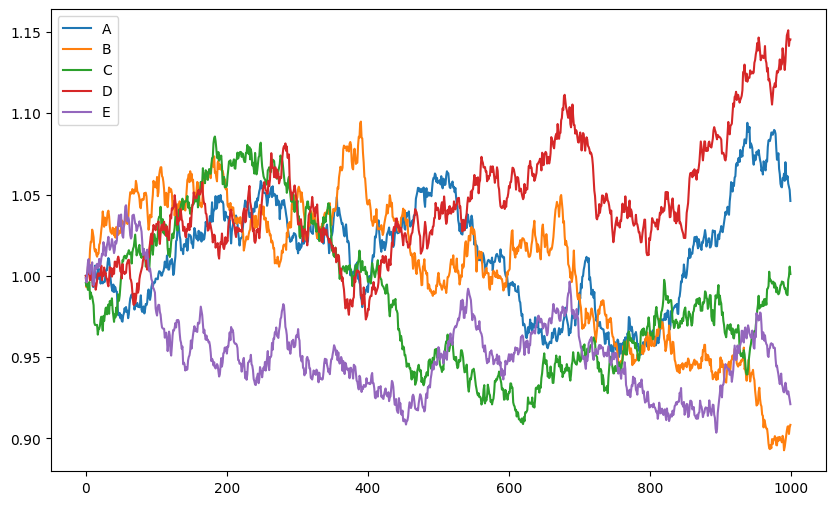

In [4]:

equity = (1+rets).cumprod()
print(equity)
equity.plot(figsize=(10,6))

                     A         B         C         D         E
mean          0.019048 -0.031982  0.003276  0.052484 -0.027271
std           0.072435  0.079102  0.076001  0.076526  0.074320
sharpe_ratio  0.262973 -0.404319  0.043102  0.685831 -0.366946
hit_rate      0.512000  0.482000  0.513000  0.514000  0.462000


<Axes: >

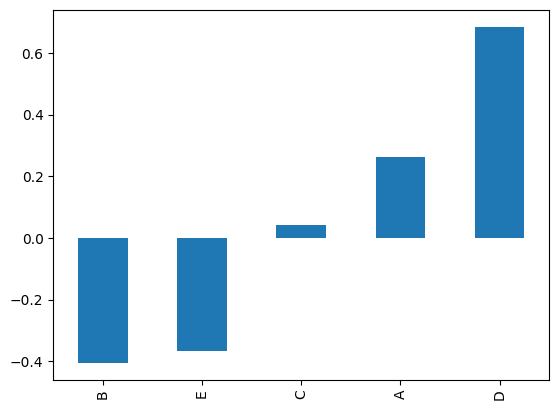

In [5]:
def compute_stats(rets):
    mean = rets.mean()*365
    std = rets.std()*np.sqrt(365)  
    sharpe_ratio = mean / std
    hit_rate = (rets > 0).sum() / len(rets)
    df = pd.DataFrame(data=[mean, std, sharpe_ratio, hit_rate], 
                      index=['mean','std','sharpe_ratio','hit_rate'], 
                      columns=columns)
    return df

stats = compute_stats(rets)
print(stats)
# plot the sharpe_ratio row from the stats DataFrame (not from rets)
stats.loc['sharpe_ratio'].sort_values().plot(kind='bar')

In [6]:

price = np.random.normal(100, 8, (1000,20))
columns = {'A':['Open','High','Low','Close'],
           'B':['Open','High','Low','Close'],
           'C':['Open','High','Low','Close'],
           'D':['Open','High','Low','Close'],
           'E':['Open','High','Low','Close']}
price = pd.DataFrame(price, columns = pd.MultiIndex.from_product([columns.keys(), ['Open','High','Low','Close']])).abs()
price

A                                               B              \
           Open        High         Low       Close        Open        High   
0     99.001187  100.701931   83.438333   96.626509  101.330464  104.436465   
1    100.452807   82.028190  101.316087  106.620382  101.869178   85.139356   
2    105.487996   85.690030  104.977783  100.067683   87.043484   98.978079   
3    101.440568   99.704103   91.387506   90.463760  107.589531   89.348251   
4    100.386637  110.879762   98.109158  100.964659   97.243317  120.400370   
..          ...         ...         ...         ...         ...         ...   
995  102.393324  102.355860  102.824267   98.766581  108.240896  108.815807   
996  107.347088  108.091743  126.405666   98.142664   91.563423  101.871524   
997  103.816247  111.909463   97.065055  101.720650  102.716747   97.032833   
998  103.572750  102.404861  112.116484  111.309202   97.849054   93.285862   
999   99.709621   98.285903   92.159612  106.184690   95.967410  104.753631   

                                      C                                      \
            Low       Close        Open        High         Low       Close   
0    104.075569  100.409124   98.218546   90.859196  119.100812  103.258378   
1    108.534875   93.778569   94.077786  105.720957   97.604993   96.466540   
2    108.656109   92.242427  100.024677   99.484309  105.048056  117.142013   
3    108.146981   99.915238  101.646274   93.188103   99.035080   94.141548   
4     88.470182  101.539800  101.979246  112.783961  108.246393  101.215488   
..          ...         ...         ...         ...         ...         ...   
995   91.006016   99.632115   99.501431   97.155100  105.244777   94.486265   
996  106.394815   90.864965   82.910678  108.186508  104.623951  101.016280   
997   95.205099   97.813001  115.693191  103.237194   97.951471  103.593996   
998  107.057347   96.060765  106.475597   99.763554  101.857905   87.770186   
999  108.610376  109.245127  101.875860   93.934537   96.418017  106.812044   

              D                                               E              \
           Open        High         Low       Close        Open        High   
0     97.985984   97.788076   97.086794   95.420808  112.586241   93.328459   
1    108.409260  101.759266  100.260032   98.496880  105.126448  105.379100   
2     84.280725  105.176831   95.468061   94.984222  108.893925  106.679110   
3     88.665708   97.679532  102.040601  104.289390   89.344250   91.139269   
4    109.059994   94.191462  111.905994  100.313395   97.352186  107.760184   
..          ...         ...         ...         ...         ...         ...   
995  106.334444  107.120890  109.424311   96.038062   90.419409   85.765330   
996  103.826732   99.565720  100.627913   97.173630  113.806840  103.244976   
997  100.994024  101.919955   92.588863   99.041869  108.631467  100.347817   
998  105.369659   91.022501  108.176477   87.610915   98.561233  104.810160   
999  105.186425   99.543228   87.009249  104.231384   97.451788   96.738520   

                             
            Low       Close  
0    109.273214  105.036414  
1    117.359833  109.285831  
2    117.404382   76.342470  
3     96.498661  112.071726  
4    104.012658  101.423381  
..          ...         ...  
995  120.417800  111.045956  
996  109.369418   97.623264  
997  103.177561   85.407939  
998  100.506510   98.339336  
999   94.284315   84.700429  

[1000 rows x 20 columns]

In [7]:
# Moment chnnel Breakout Strategy 
def breakout_multi(price, X, Y, M, N):
    """
    price: MultiIndex columns (asset, field)
           fields must include ['High', 'Low'] for each asset.

    Returns:
        A DataFrame with MultiIndex columns (asset, 'position')
    """
    
    assets = price.columns.get_level_values(0).unique()
    
    results = {}
    
    for asset in assets:
        df = price[asset].copy()   # slice asset's OHLC
        
        # Rolling windows (shifted to avoid lookahead)
        df['Y_high'] = df['High'].rolling(Y).max().shift(1)
        df['X_low']  = df['Low'].rolling(X).min().shift(1)
        df['N_low']  = df['Low'].rolling(N).min().shift(1)
        df['M_high'] = df['High'].rolling(M).max().shift(1)

        # Signals
        df['long_entry']  = (df['High'] >= df['Y_high']).astype(int)
        df['long_exit']   = (df['Low']  <= df['X_low']).astype(int)
        df['short_entry'] = (df['Low']  <= df['N_low']).astype(int)
        df['short_exit']  = (df['High'] >= df['M_high']).astype(int)

        # Position vector
        pos = np.zeros(len(df))
        for i in range(1, len(df)):
            pos[i] = pos[i-1]

            # exits
            if pos[i] == 1 and df['long_exit'].iloc[i]:
                pos[i] = 0
            elif pos[i] == -1 and df['short_exit'].iloc[i]:
                pos[i] = 0

            # entries (only if flat)
            if pos[i] == 0:
                if df['long_entry'].iloc[i]:
                    pos[i] = 1
                elif df['short_entry'].iloc[i]:
                    pos[i] = -1
        
        results[(asset, 'position')] = pos

    # Return result as MultiIndex DataFrame
    return pd.DataFrame(results)

In [8]:
mu = rets.mean()
sigma = rets.cov()

def optimal_weights(sigma,mu):
    wgt = np.linalg.inv(sigma) @ mu 
    wgt = wgt / np.abs(wgt).sum()
    return wgt

wgt = optimal_weights(sigma,mu)
combo = (rets*wgt).sum(1)
combo.mean()/combo.std()*np.sqrt(252)
wgt

array([ 0.10307457, -0.22147151,  0.04327601,  0.39362991, -0.23854799])

In [9]:
A = price.loc[:, ('A', slice(None))]
A

A                                    
           Open        High         Low       Close
0     99.001187  100.701931   83.438333   96.626509
1    100.452807   82.028190  101.316087  106.620382
2    105.487996   85.690030  104.977783  100.067683
3    101.440568   99.704103   91.387506   90.463760
4    100.386637  110.879762   98.109158  100.964659
..          ...         ...         ...         ...
995  102.393324  102.355860  102.824267   98.766581
996  107.347088  108.091743  126.405666   98.142664
997  103.816247  111.909463   97.065055  101.720650
998  103.572750  102.404861  112.116484  111.309202
999   99.709621   98.285903   92.159612  106.184690

[1000 rows x 4 columns]

In [10]:
A = price.loc[:, ('A', slice(None))]
positions = breakout_multi(A, X=3, Y=23, M=7, N=6)
positions = positions.copy()
positions.columns = positions.columns.get_level_values(0)
positionsA = positions

In [11]:
B = price.loc[:, ('B', slice(None))]
positions = breakout_multi(B, X=37, Y=55, M=50, N=35)
positions = positions.copy()
positions.columns = positions.columns.get_level_values(0)
positionsB = positions

In [12]:
C = price.loc[:, ('C', slice(None))]
positions = breakout_multi(C, X=1, Y=14, M=14, N=3)
positions = positions.copy()
positions.columns = positions.columns.get_level_values(0)
positionsC = positions

In [13]:
D = price.loc[:, ('D', slice(None))]
positions = breakout_multi(D, X=1, Y=1, M=1, N=1)
positions = positions.copy()
positions.columns = positions.columns.get_level_values(0)
positionsD = positions

In [14]:
E = price.loc[:, ('E', slice(None))]
positions = breakout_multi(E, X=1, Y=10, M=27, N=27)
positions = positions.copy()
positions.columns = positions.columns.get_level_values(0)
positionsE = positions

In [15]:
positions = pd.concat(
    [positionsA, positionsB, positionsC, positionsD, positionsE],
    axis=1
)
positions

,A,B,C,D,E
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...
995,0.0,-1.0,-1.0,1.0,0.0
996,0.0,-1.0,-1.0,-1.0,0.0
997,0.0,-1.0,-1.0,1.0,0.0
998,0.0,-1.0,-1.0,1.0,0.0


In [16]:
window = 91
weight = []

for i in range(window, len(rets), window):

    train = rets.iloc[:i]               # data available at time i
    test  = rets.iloc[i:i+window]       # next period to trade

    pos_test = positions.iloc[i:i+window]

    mu = train.mean()
    sigma = train.cov()

    wgt = optimal_weights(sigma, mu)

    period_returns = (test * pos_test.shift() * wgt)

    weight.append(period_returns)

portfolio = pd.concat(weight)

Average return: 0.00012270429188755992


<Axes: >

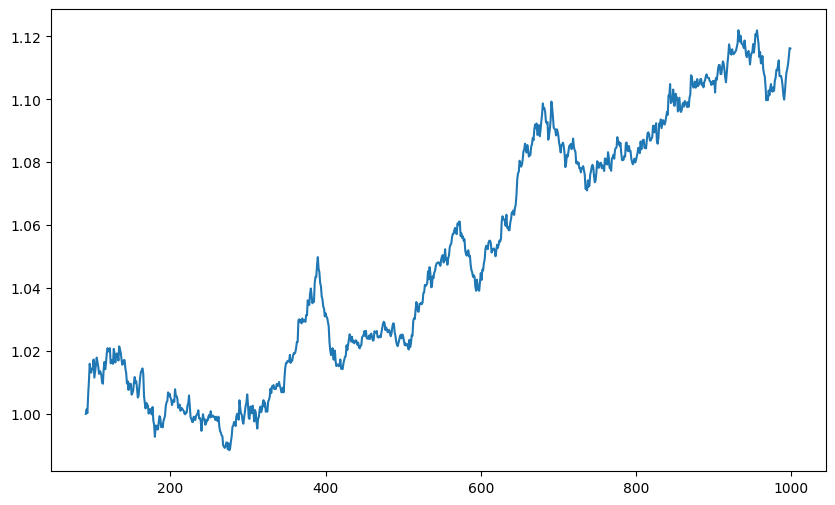

In [17]:
strategy_returns = portfolio.sum(axis=1) 
print("Average return:", strategy_returns.mean())
(strategy_returns + 1).cumprod().plot(figsize=(10,6))

<Axes: >

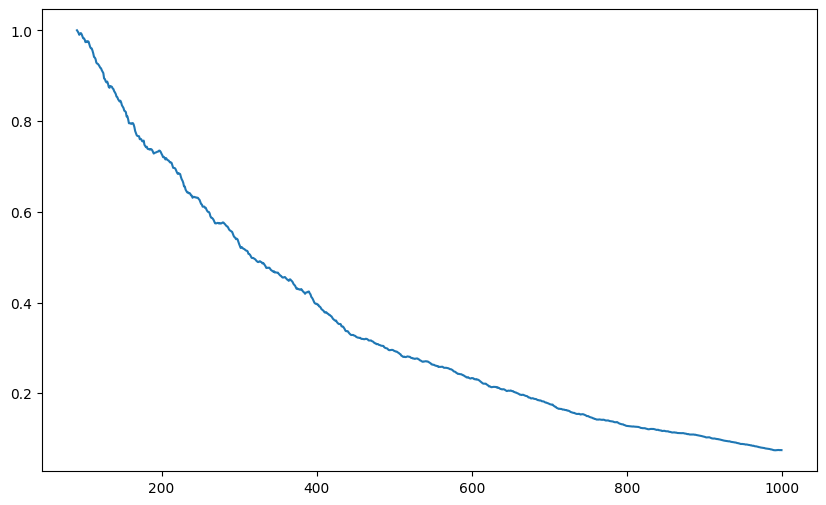

In [18]:
strategy_returns2 = portfolio.sum(axis=1)

to = (positions.fillna(0) - positions.shift().fillna(0)).abs().sum(1)

to_aligned = to.loc[strategy_returns2.index]

net_ret = strategy_returns2 - to_aligned * 20 * 1e-4

(net_ret + 1).cumprod().plot(figsize=(10,6))

In [19]:
to.mean()

np.float64(1.486)

In [20]:
net_ret.mean()/net_ret.std()*np.sqrt(365)

np.float64(-16.706821834029924)

In [21]:
def sharpe_ratio(rets):  
    mean = rets.mean()*365
    std = rets.std()*np.sqrt(365)  
    sharpe_ratio = mean / std
    return sharpe_ratio
sharpe_ratio(net_ret)

np.float64(-16.706821834029927)

In [22]:
strategy_returns

91     0.000000
92     0.001406
93    -0.001160
94     0.005742
95     0.004385
         ...   
995    0.000880
996    0.001407
997    0.002041
998    0.002527
999   -0.000103
Length: 909, dtype: float64

In [23]:
# Training:   2018–2022
# Validation: 2023–2024
# strategy_return = alpha + beta * benchmark + error

In [24]:
split = int(len(strategy_returns) * 0.8)

train = rets.iloc[:split]
test  = rets.iloc[split:]

In [25]:
mu_train = train.mean()
sigma_train = train.cov()

wgt = optimal_weights(sigma_train, mu_train)

In [26]:
strategy_train = (train * wgt).sum(axis=1)
strategy_test  = (test * wgt).sum(axis=1)

In [27]:
print("Train Sharpe:", strategy_train.mean()/strategy_train.std()*np.sqrt(365))
print("Test Sharpe:", strategy_test.mean()/strategy_test.std()*np.sqrt(365))

Train Sharpe: 0.5797519955502428
Test Sharpe: 0.2715973514163111


In [28]:
benchmark = rets.mean(axis=1)

In [29]:
window = 91
weight = []

for i in range(window, len(rets), window):

    train = rets.iloc[:i]               # data available at time i
    test  = rets.iloc[i:i+window]       # next period to trade

    pos_test = positions.iloc[i:i+window]

    mu = train.mean()
    sigma = train.cov()

    wgt = optimal_weights(sigma, mu)

    period_returns = (test * pos_test.shift() * wgt).sum(axis=1)

    weight.append(period_returns)

portfolio = pd.concat(weight)

benchmark = benchmark.loc[portfolio.index]

split = int(len(portfolio)*0.8)

train_strategy = portfolio.iloc[:split]
test_strategy = portfolio.iloc[split:]

benchmark_train = benchmark.iloc[:split]
benchmark_test  = benchmark.iloc[split:]


# regression
import statsmodels.api as sm

X_train = sm.add_constant(benchmark_train)
model_train = sm.OLS(train_strategy, X_train).fit()

X_test = sm.add_constant(benchmark_test)
model_test = sm.OLS(test_strategy, X_test).fit()

print("Train alpha t-stat:", model_train.tvalues['const'])
print("Test alpha t-stat:", model_test.tvalues['const'])

Train alpha t-stat: 1.87181360703744
Test alpha t-stat: 0.6317436696066866


In [30]:
print(model_train.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     33.68
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           9.72e-09
Time:                        14:51:45   Log-Likelihood:                 3551.2
No. Observations:                 727   AIC:                            -7098.
Df Residuals:                     725   BIC:                            -7089.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001    6.8e-05      1.872      0.0

In [31]:
print(model_test.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     19.37
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.84e-05
Time:                        14:51:45   Log-Likelihood:                 885.33
No. Observations:                 182   AIC:                            -1767.
Df Residuals:                     180   BIC:                            -1760.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.821e-05      0.000      0.632      0.5

In [32]:
closing = price[[('A', 'Close'),('B', 'Close'),('C', 'Close'),('D', 'Close'),('E', 'Close')]]
closing = closing.droplevel(1, axis=1)

In [33]:
closing = pd.DataFrame(closing)
closing

,A,B,C,D,E
0,96.626509,100.409124,103.258378,95.420808,105.036414
1,106.620382,93.778569,96.466540,98.496880,109.285831
2,100.067683,92.242427,117.142013,94.984222,76.342470
3,90.463760,99.915238,94.141548,104.289390,112.071726
4,100.964659,101.539800,101.215488,100.313395,101.423381
...,...,...,...,...,...
995,98.766581,99.632115,94.486265,96.038062,111.045956
996,98.142664,90.864965,101.016280,97.173630,97.623264
997,101.720650,97.813001,103.593996,99.041869,85.407939
998,111.309202,96.060765,87.770186,87.610915,98.339336


In [34]:
def EMA(closing, window = 34):
    ema = closing.ewm(span=window, adjust=False).mean()
    return ema

def EMA_2(closing, window = 18):
    ema_2 = closing.ewm(span=window, adjust=False).mean()
    return ema_2


In [35]:
ema = EMA(closing, window=20)
ema_2 = EMA_2(closing, window=40)

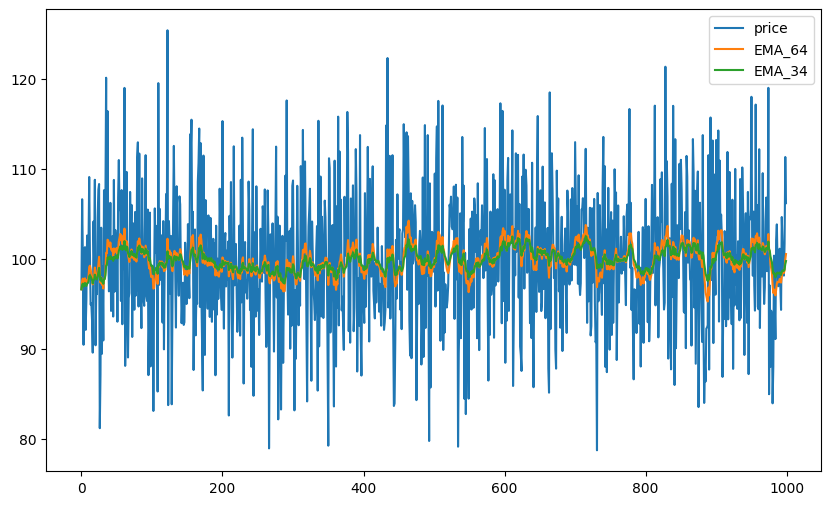

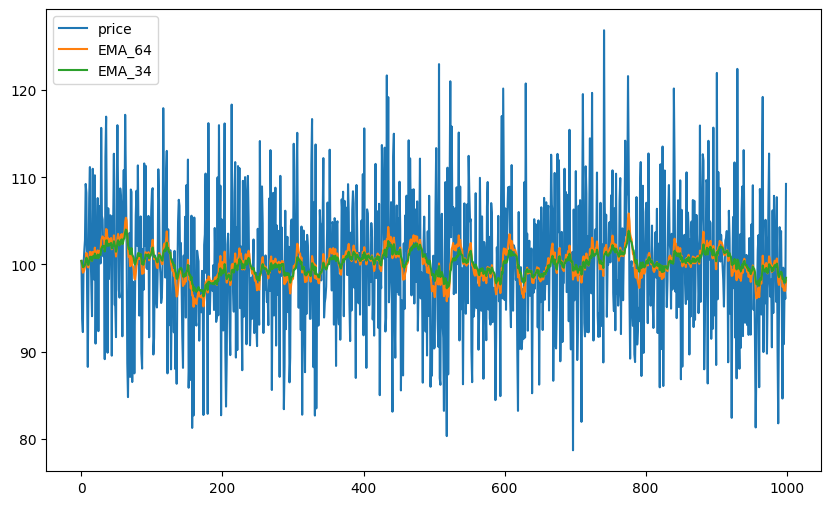

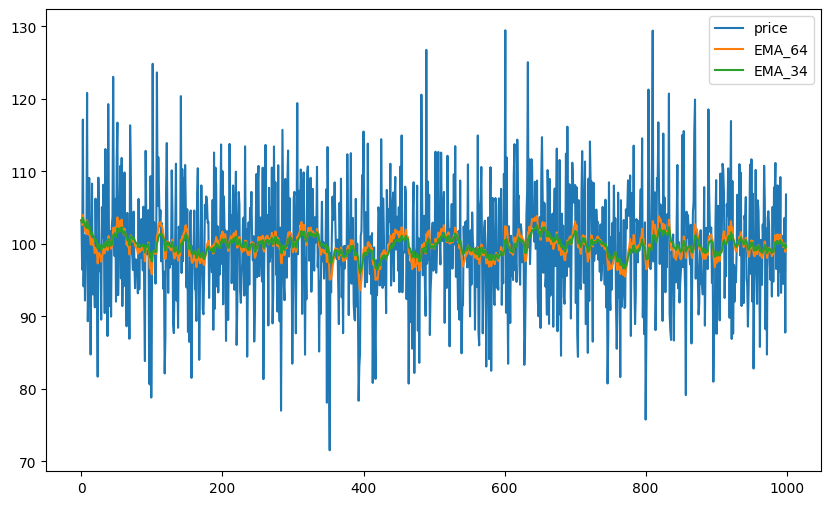

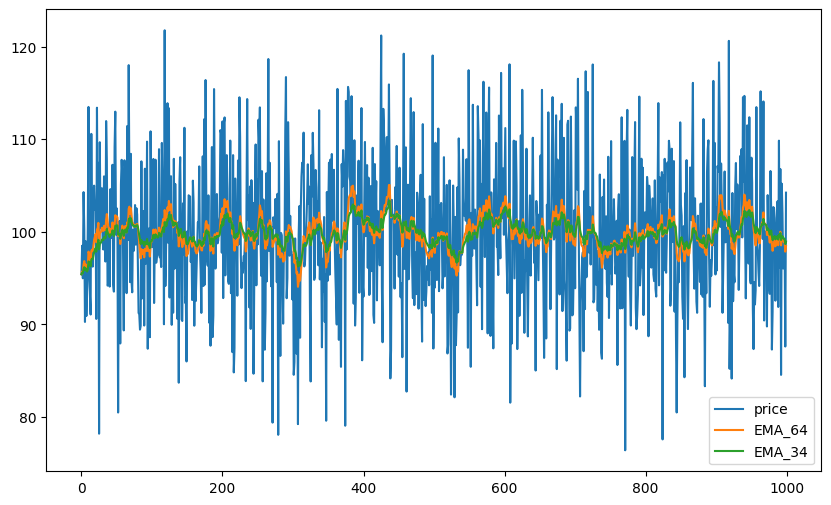

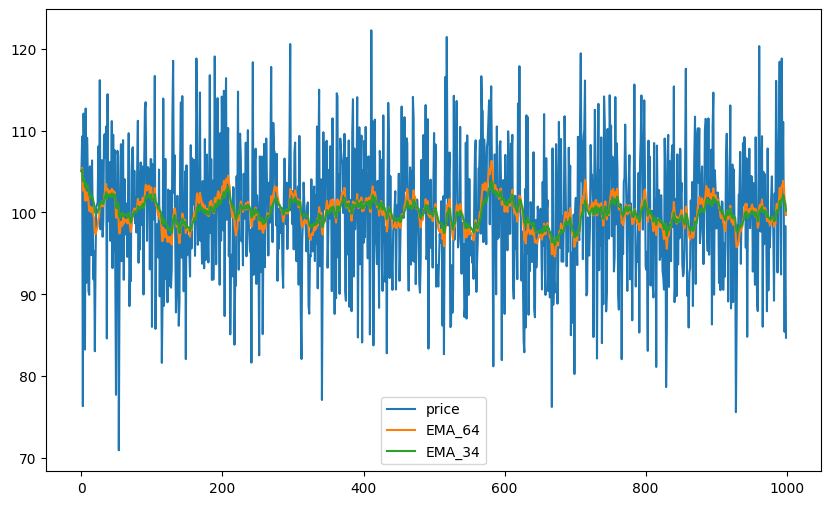

In [36]:
data = []

for i in closing.columns:
    stock = pd.DataFrame({
        'price'  : closing[i],
        'EMA_64' : ema[i],
        'EMA_34' : ema_2[i],
        'ticker' : i
    })

    stock[['price', 'EMA_64', 'EMA_34']].plot(figsize=(10,6))

    data.append(stock)

In [37]:
combined_df = pd.concat(data, axis=0)
data_A = combined_df.iloc[0:1000]
data_B = combined_df.iloc[1000:2000]
data_C = combined_df.iloc[2000:3000]
data_D = combined_df.iloc[3000:4000]
data_E = combined_df.iloc[4000:5000]
data = [data_A, data_B, data_C, data_D, data_E]

In [38]:
def ema_signal(df):
    diff = df['EMA_34'] - df['EMA_64']
    signal = np.sign(diff).fillna(0).astype(int)
    return pd.Series(signal, index=df.index)

signals = []

for df in data:
    s = ema_signal(df)
    signals.append(s)
signals = pd.concat(signals, axis=1, keys=rets.columns)
signals

,A,B,C,D,E
0,0,0,0,0,0
1,-1,1,1,-1,-1
2,-1,1,-1,-1,1
3,-1,1,1,-1,1
4,-1,1,1,-1,1
...,...,...,...,...,...
995,1,1,1,1,-1
996,1,1,1,1,-1
997,1,1,-1,1,-1
998,-1,1,1,1,-1


In [39]:
window = 91
weight = []

for i in range(window, len(rets), window):

    train = rets.iloc[:i]               # data available at time i
    test  = rets.iloc[i:i+window]       # next period to trade

    pos_test = signals.iloc[i:i+window]

    mu = train.mean()
    sigma = train.cov()

    wgt = optimal_weights(sigma, mu)

    period_returns = (test * pos_test.shift() * wgt)

    weight.append(period_returns)

portfolio = pd.concat(weight)

<Axes: >

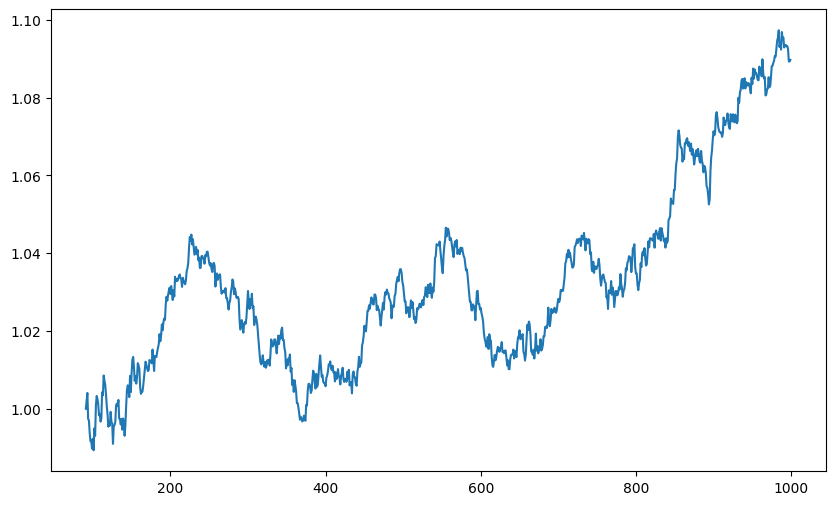

In [40]:
stocks_rets = portfolio.sum(axis=1)
(1+stocks_rets).cumprod().plot(figsize=(10,6))

<Axes: >

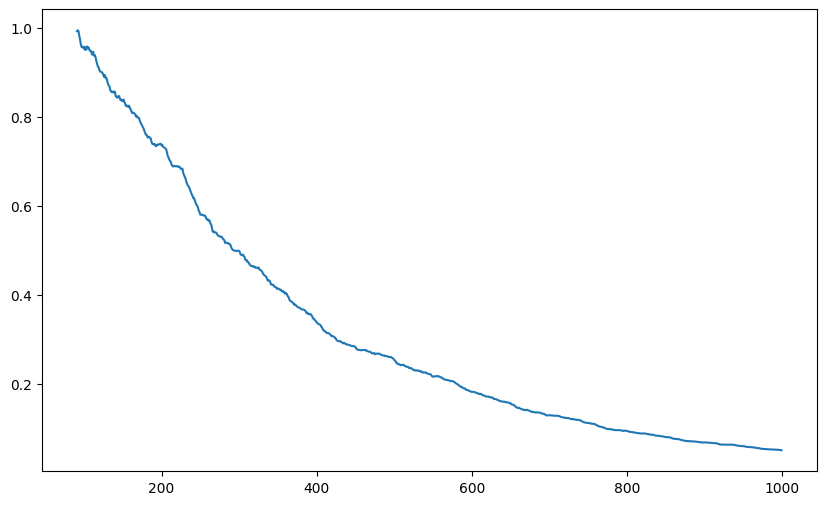

In [41]:
stock_profits = portfolio.sum(axis=1) 

to = (signals.fillna(0) - signals.shift().fillna(0)).abs().sum(1)

to_aligned = to.loc[stock_profits.index]

net_ret = stock_profits - to_aligned * 20 * 1e-4

(1+net_ret).cumprod().plot(figsize=(10,6))

In [42]:
sharpe_ratio(net_ret)

np.float64(-16.0658608531875)

In [43]:
window = 91
weight = []

for i in range(window, len(rets), window):

    train = rets.iloc[:i]               # data available at time i
    test  = rets.iloc[i:i+window]       # next period to trade

    pos_test = signals.iloc[i:i+window]

    mu = train.mean()
    sigma = train.cov()

    wgt = optimal_weights(sigma, mu)

    period_returns = (test * pos_test.shift() * wgt).sum(axis=1)

    weight.append(period_returns)

portfolio = pd.concat(weight)

benchmark = benchmark.loc[portfolio.index]

split = int(len(portfolio)*0.8)

train_strategy = portfolio.iloc[:split]
test_strategy = portfolio.iloc[split:]

benchmark_train = benchmark.iloc[:split]
benchmark_test  = benchmark.iloc[split:]


# regression
import statsmodels.api as sm

X_train = sm.add_constant(benchmark_train)
model_train = sm.OLS(train_strategy, X_train).fit()

X_test = sm.add_constant(benchmark_test)
model_test = sm.OLS(test_strategy, X_test).fit()

print("Train alpha t-stat:", model_train.tvalues['const'])
print("Test alpha t-stat:", model_test.tvalues['const'])

Train alpha t-stat: 0.7503768137305107
Test alpha t-stat: 1.542278216601285


In [44]:
print(model_train.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.129
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.288
Time:                        14:51:46   Log-Likelihood:                 3479.4
No. Observations:                 727   AIC:                            -6955.
Df Residuals:                     725   BIC:                            -6946.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.629e-05    7.5e-05      0.750      0.4

In [45]:
print(model_test.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     5.547
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0196
Time:                        14:51:46   Log-Likelihood:                 879.38
No. Observations:                 182   AIC:                            -1755.
Df Residuals:                     180   BIC:                            -1748.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.542      0.1

In [46]:
# Real data starts here

In [47]:
from binance.client import Client as bnb_client
from datetime import datetime

client = bnb_client(tld='US')

def get_binance_px(symbol,freq,start_ts = '2022-01-01'):
    data = client.get_historical_klines(symbol,freq,start_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
    data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
    return data 

univ = ['BTC','ETH','USDT','BNB','USDe','USDC',
        'SOL','LTC','DOGE','ADA','BCH','LINK',
        'ZEC','XMR','XLM']

symbols = [f"{s}USDT" for s in univ]

freq = '4h'

px = {}
for x in symbols:
    try:
        data = get_binance_px(x, freq, "1 Jan, 2022")
        px[x] = data.set_index('open_time')['close'].astype(float)
    except Exception as e:
        print(f"Skipping {x}: {e}")
px = pd.DataFrame(px).astype(float)
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))
px = px.ffill()
for col in px.columns:
    first_valid = px[col].first_valid_index()
    px.loc[px.index < first_valid, col] = np.nan
ret = px.pct_change()

C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:7: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  data = client.get_historical_klines(symbol,freq,start_ts)
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:14: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:15: DeprecationWarning: datetime.datetime.utcfromtim

Skipping USDTUSDT: APIError(code=-1121): Invalid symbol.


C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:14: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:15: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:7: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior w

Skipping USDeUSDT: APIError(code=-1100): Illegal characters found in parameter 'symbol'; legal range is '^[A-Z0-9-_.]{1,20}$'.


C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:14: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:15: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:7: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior w

Skipping XMRUSDT: APIError(code=-1121): Invalid symbol.


C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:14: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:15: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))


In [48]:
cols = [
    'open','high','low','close','volume','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume'
]
price_data = {}
for x in symbols:
    try:
        data = get_binance_px(x, freq, "1 Jan, 2022")
        price_data[x] = data.set_index('open_time')[cols].astype(float)
    except Exception as e:
        print(f"Skipping {x}: {e}")
price_data = pd.concat(price_data, axis=1)
price_data = price_data.reindex(
    pd.date_range(price_data.index[0], price_data.index[-1], freq=freq)
)

price_data = price_data.ffill()

C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:7: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  data = client.get_historical_klines(symbol,freq,start_ts)
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:14: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:15: DeprecationWarning: datetime.datetime.utcfromtim

Skipping USDTUSDT: APIError(code=-1121): Invalid symbol.


C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:14: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:15: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:7: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior w

Skipping USDeUSDT: APIError(code=-1100): Illegal characters found in parameter 'symbol'; legal range is '^[A-Z0-9-_.]{1,20}$'.


C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:14: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:15: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:7: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior w

Skipping XMRUSDT: APIError(code=-1121): Invalid symbol.


C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:14: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
C:\Users\david\AppData\Local\Temp\ipykernel_27360\3728653088.py:15: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))


In [49]:
price_data = price_data.dropna()
price_data

BTCUSDT                                           \
                         open      high       low     close     volume   
2022-01-14 00:00:00  42585.13  42780.42  42379.68  42659.64  14.709274   
2022-01-14 04:00:00  42659.65  42965.43  42606.27  42608.43  11.740515   
2022-01-14 08:00:00  42626.34  42684.34  41830.23  42017.84  35.152917   
2022-01-14 12:00:00  41998.05  43342.01  41770.37  43107.95  47.775561   
2022-01-14 16:00:00  43115.64  43411.31  42770.56  43091.54  27.264429   
...                       ...       ...       ...       ...        ...   
2026-03-19 04:00:00  71181.57  71199.40  69669.00  70194.36  14.376650   
2026-03-19 08:00:00  70258.08  70518.64  69927.98  69927.98   1.492660   
2026-03-19 12:00:00  69914.46  70223.01  68791.95  69524.70   3.274420   
2026-03-19 16:00:00  69401.20  70583.87  69131.81  70239.67   4.445250   
2026-03-19 20:00:00  70249.37  70655.06  70224.55  70464.65   0.149860   

                                                                \
                     quote_volume num_trades taker_base_volume   
2022-01-14 00:00:00  6.268863e+05      979.0          8.353812   
2022-01-14 04:00:00  5.019248e+05      902.0          5.684794   
2022-01-14 08:00:00  1.482846e+06     1500.0         18.931404   
2022-01-14 12:00:00  2.040749e+06     2276.0         30.696696   
2022-01-14 16:00:00  1.176077e+06     1512.0         14.088917   
...                           ...        ...               ...   
2026-03-19 04:00:00  1.013341e+06      712.0          2.073710   
2026-03-19 08:00:00  1.047550e+05      102.0          0.198480   
2026-03-19 12:00:00  2.275557e+05      438.0          1.874510   
2026-03-19 16:00:00  3.111104e+05      292.0          3.760390   
2026-03-19 20:00:00  1.053991e+04       45.0          0.091610   

                                        ETHUSDT  ...            ZECUSDT  \
                    taker_quote_volume     open  ... taker_quote_volume   
2022-01-14 00:00:00       3.559922e+05  3239.22  ...         2007.83480   
2022-01-14 04:00:00       2.430958e+05  3268.28  ...         1192.12540   
2022-01-14 08:00:00       7.981168e+05  3266.19  ...        12010.80280   
2022-01-14 12:00:00       1.311283e+06  3207.43  ...          151.55520   
2022-01-14 16:00:00       6.080210e+05  3279.14  ...         8191.24980   
...                                ...      ...  ...                ...   
2026-03-19 04:00:00       1.454719e+05  2210.19  ...          756.84768   
2026-03-19 08:00:00       1.392593e+04  2169.46  ...         1339.48510   
2026-03-19 12:00:00       1.304449e+05  2167.08  ...         7324.90245   
2026-03-19 16:00:00       2.631835e+05  2117.80  ...         1520.68776   
2026-03-19 20:00:00       6.446342e+03  2140.51  ...          900.97005   

                     XLMUSDT                                       \
                        open     high      low    close    volume   
2022-01-14 00:00:00  0.26950  0.27111  0.26688  0.27017  224892.6   
2022-01-14 04:00:00  0.26980  0.27860  0.26979  0.27549  178525.4   
2022-01-14 08:00:00  0.27559  0.27575  0.26256  0.26490  302795.0   
2022-01-14 12:00:00  0.26450  0.26988  0.26146  0.26803  252024.5   
2022-01-14 16:00:00  0.26881  0.26967  0.26637  0.26843  389575.0   
...                      ...      ...      ...      ...       ...   
2026-03-19 04:00:00  0.16980  0.16980  0.16740  0.16740    2847.0   
2026-03-19 08:00:00  0.16750  0.16820  0.16690  0.16810   24236.0   
2026-03-19 12:00:00  0.16540  0.16870  0.16220  0.16420    4697.0   
2026-03-19 16:00:00  0.16420  0.16620  0.16250  0.16620    3793.0   
2026-03-19 20:00:00  0.16560  0.16560  0.16560  0.16560     301.0   

                                                                 \
                      quote_volume num_trades taker_base_volume   
2022-01-14 00:00:00   60695.710729      156.0          172650.7   
2022-01-14 04:00:00   49046.075417      173.0           91139.1   
2022-01-14 08:00:00   80934.635457      222.0          201

In [50]:
px = px.dropna()
px

,BTCUSDT,ETHUSDT,BNBUSDT,USDCUSDT,SOLUSDT,LTCUSDT,DOGEUSDT,ADAUSDT,BCHUSDT,LINKUSDT,ZECUSDT,XLMUSDT
2022-01-14 00:00:00,42659.64,3268.58,480.8159,0.9998,147.7462,138.27,0.175999,1.24693,383.41,25.20,141.60,0.27017
2022-01-14 04:00:00,42608.43,3265.00,484.2211,0.9995,147.5973,138.72,0.196018,1.28331,387.98,24.94,142.20,0.27549
2022-01-14 08:00:00,42017.84,3202.73,472.1416,0.9994,143.3609,138.51,0.188406,1.23350,380.61,24.07,138.00,0.26490
2022-01-14 12:00:00,43107.95,3275.66,481.4952,0.9998,147.0490,144.74,0.194120,1.26562,389.78,24.72,142.40,0.26803
2022-01-14 16:00:00,43091.54,3307.99,486.1436,0.9998,148.3940,144.64,0.187657,1.26316,388.18,24.93,143.60,0.26843
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-19 04:00:00,70194.36,2166.91,646.3800,1.0003,89.5900,55.48,0.094470,0.26970,453.90,9.14,244.94,0.16740
2026-03-19 08:00:00,69927.98,2169.19,645.1200,0.9998,89.5600,55.56,0.093860,0.26910,456.00,9.16,244.11,0.16810
2026-03-19 12:00:00,69524.70,2119.00,638.1100,1.0000,87.7300,54.78,0.093020,0.26530,454.60,8.91,237.83,0.16420
2026-03-19 16:00:00,70239.67,2139.60,641.3000,0.9998,88.8400,55.63,0.094010,0.26760,455.90,9.07,236.41,0.16620


In [51]:
ret = ret.dropna()
ret

,BTCUSDT,ETHUSDT,BNBUSDT,USDCUSDT,SOLUSDT,LTCUSDT,DOGEUSDT,ADAUSDT,BCHUSDT,LINKUSDT,ZECUSDT,XLMUSDT
2022-01-14 04:00:00,-0.001200,-0.001095,0.007082,-0.0003,-0.001008,0.003255,0.113740,0.029176,0.011919,-0.010317,0.004237,0.019691
2022-01-14 08:00:00,-0.013861,-0.019072,-0.024946,-0.0001,-0.028702,-0.001514,-0.038833,-0.038814,-0.018996,-0.034884,-0.029536,-0.038441
2022-01-14 12:00:00,0.025944,0.022771,0.019811,0.0004,0.025726,0.044979,0.030332,0.026040,0.024093,0.027005,0.031884,0.011816
2022-01-14 16:00:00,-0.000381,0.009870,0.009654,0.0000,0.009147,-0.000691,-0.033297,-0.001944,-0.004105,0.008495,0.008427,0.001492
2022-01-14 20:00:00,-0.000371,-0.000466,0.008266,-0.0003,-0.014671,-0.000691,-0.023501,0.021628,-0.008913,0.034095,-0.006964,-0.014268
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-19 04:00:00,-0.014816,-0.021008,-0.009212,0.0004,-0.012891,-0.010699,-0.010474,-0.018202,-0.009601,-0.014024,-0.031092,-0.015873
2026-03-19 08:00:00,-0.003795,0.001052,-0.001949,-0.0005,-0.000335,0.001442,-0.006457,-0.002225,0.004627,0.002188,-0.003389,0.004182
2026-03-19 12:00:00,-0.005767,-0.023138,-0.010866,0.0002,-0.020433,-0.014039,-0.008949,-0.014121,-0.003070,-0.027293,-0.025726,-0.023200
2026-03-19 16:00:00,0.010284,0.009722,0.004999,-0.0002,0.012652,0.015517,0.010643,0.008669,0.002860,0.017957,-0.005971,0.012180


<Axes: >

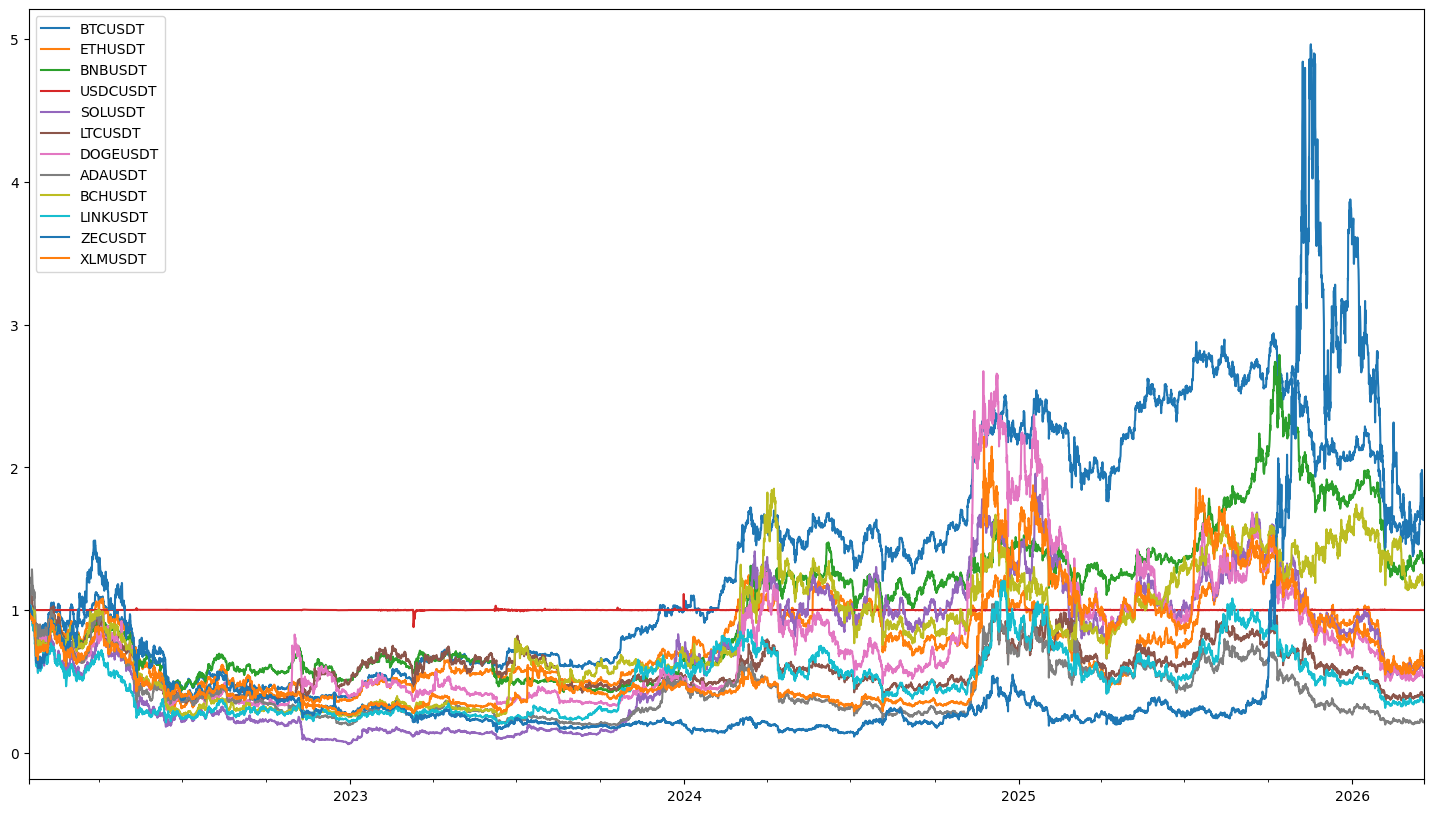

In [52]:
equity = (1+ret).cumprod()

equity.plot(figsize=(18,10))

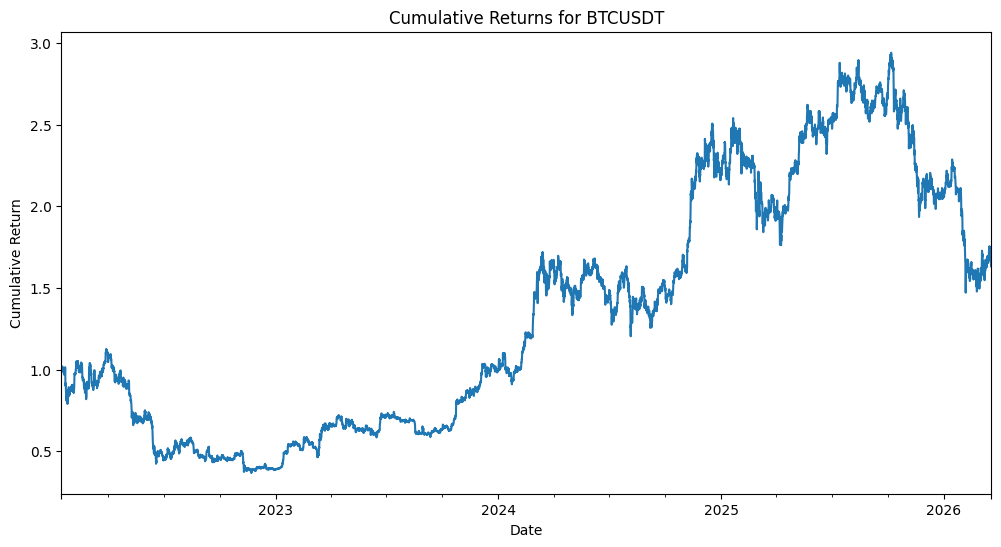

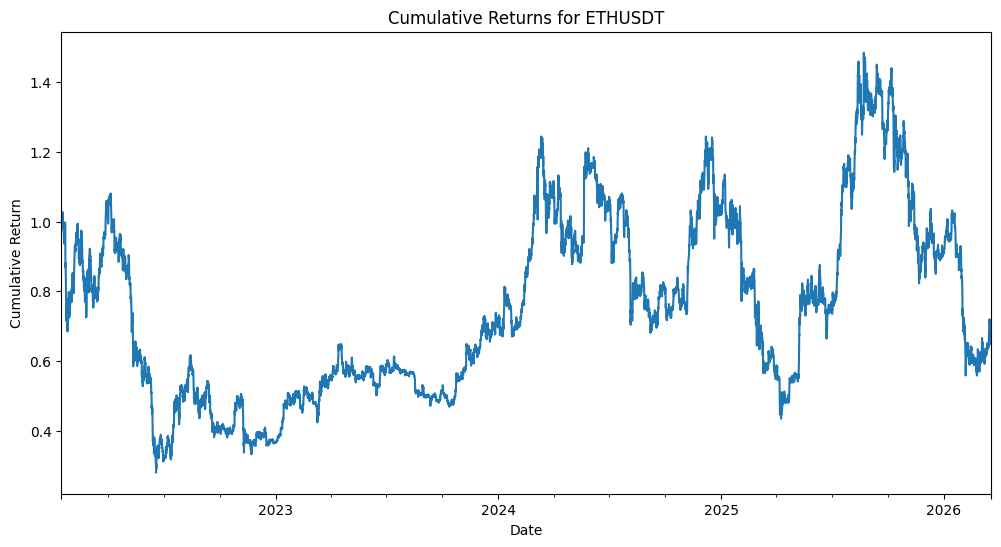

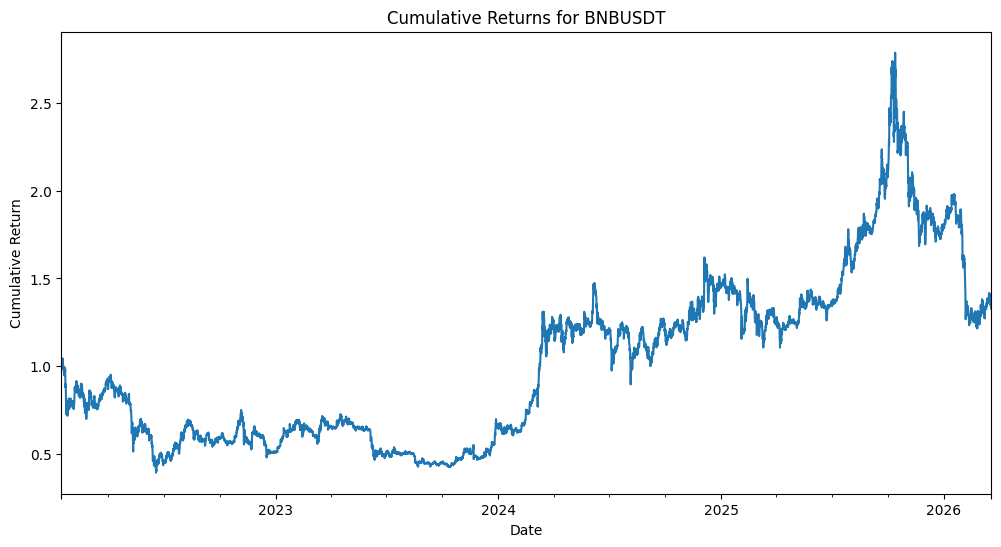

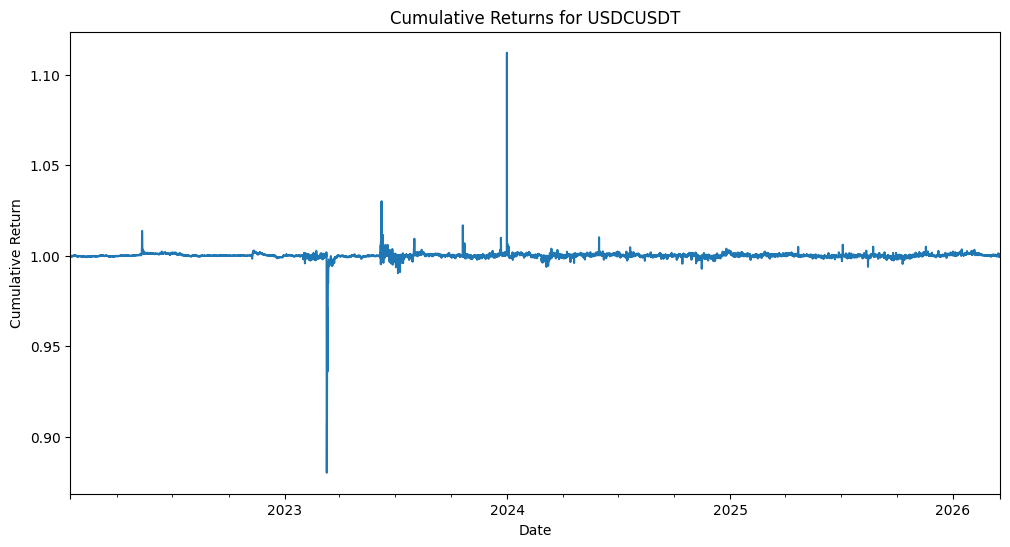

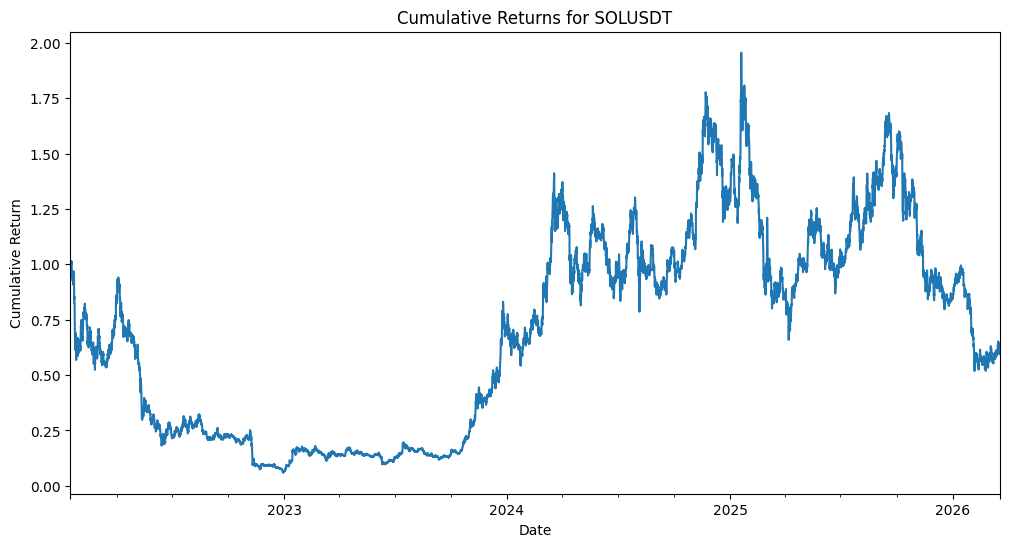

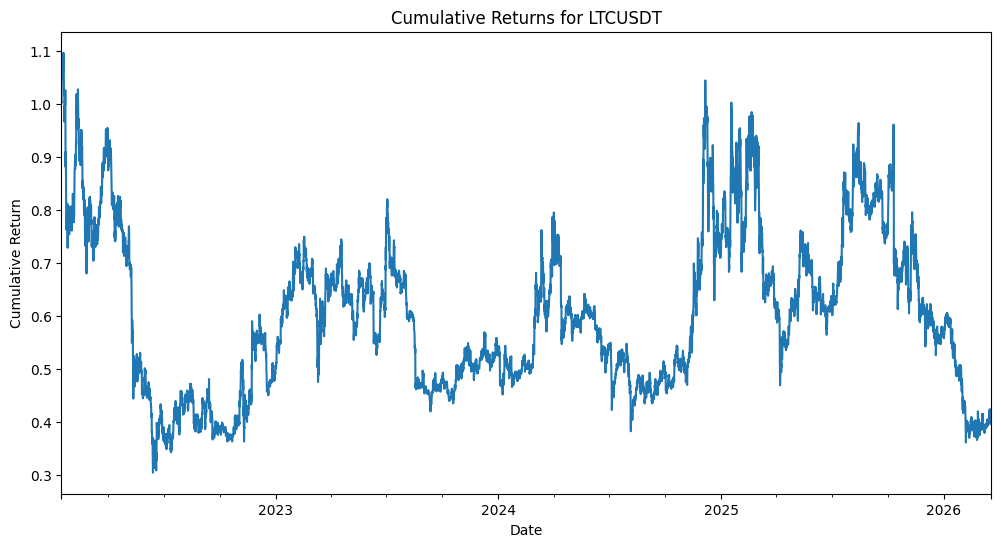

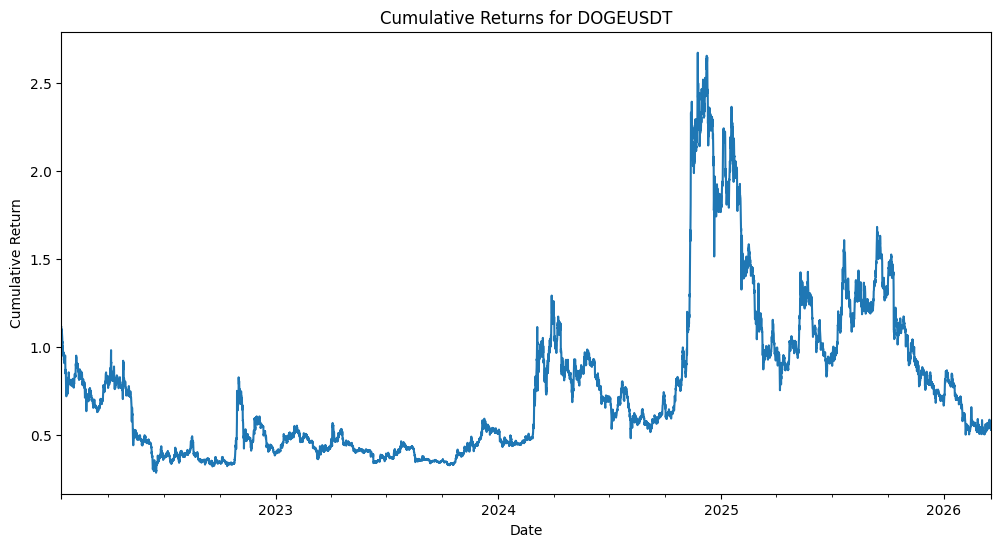

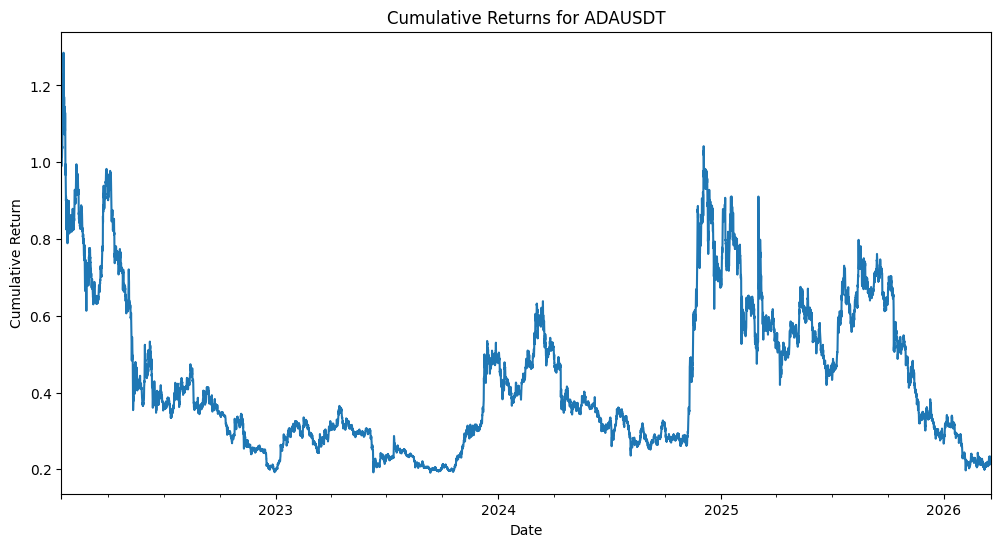

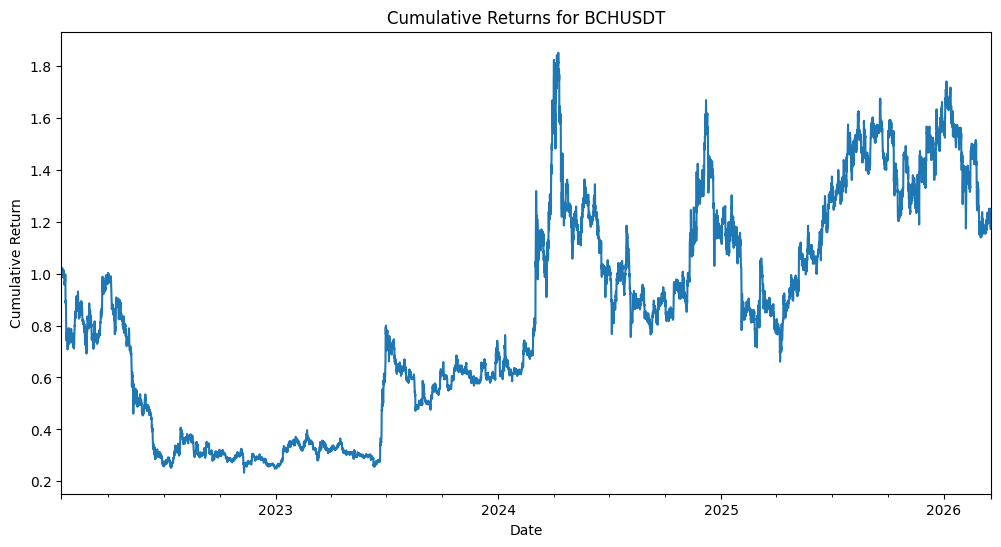

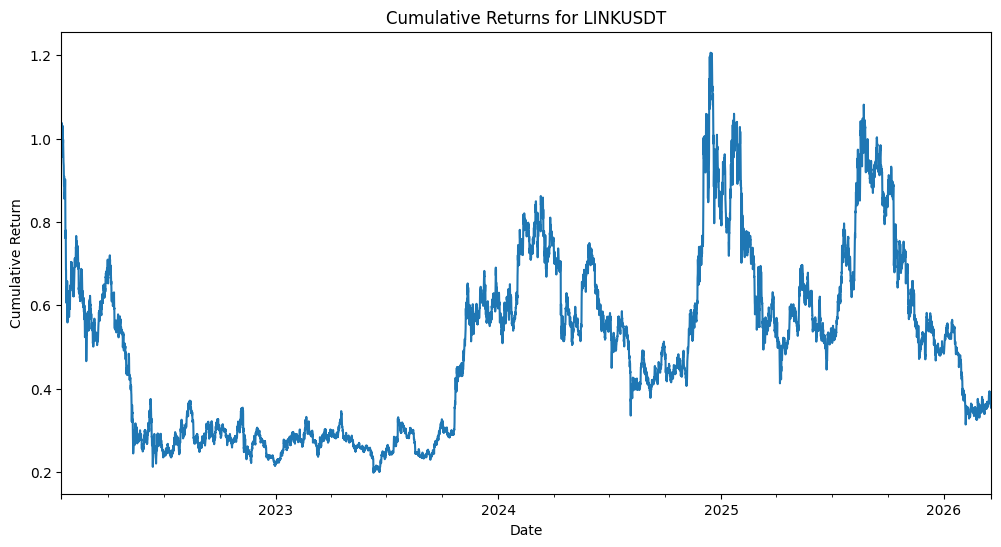

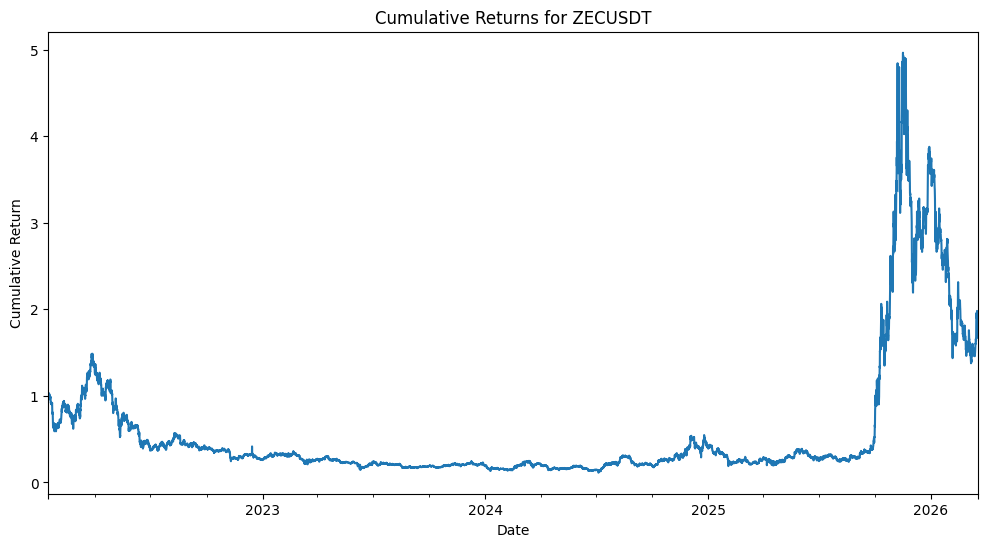

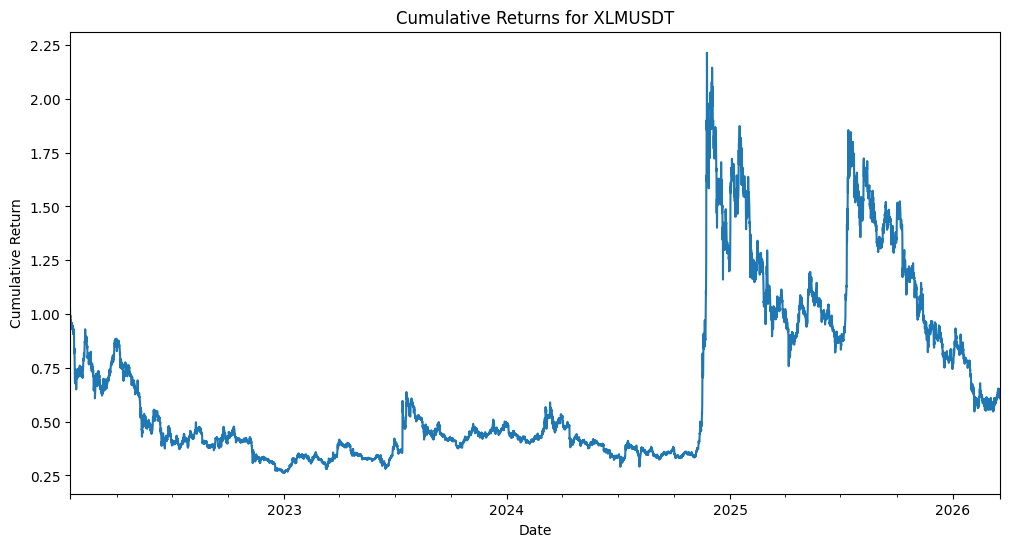

In [53]:
for i in ret.columns:  # make sure you loop over columns, not the DataFrame itself
    (1 + ret[i]).cumprod().plot(figsize=(12,6), title=f"Cumulative Returns for {i}")
    plt.xlabel("Date") 
    plt.ylabel("Cumulative Return")
    plt.show() 

               BTCUSDT   ETHUSDT   BNBUSDT  USDCUSDT   SOLUSDT   LTCUSDT  \
mean          0.041039  0.021631  0.040385  0.000882  0.057106  0.016567   
std           0.205042  0.276863  0.240062  0.041916  0.393667  0.323915   
sharpe_ratio  0.200149  0.078128  0.168226  0.021043  0.145062  0.051147   
hit_rate      0.513818  0.508138  0.513708  0.393774  0.502567  0.508138   

              DOGEUSDT   ADAUSDT   BCHUSDT  LINKUSDT   ZECUSDT   XLMUSDT  
mean          0.047738  0.002835  0.070249  0.026026  0.157190  0.041296  
std           0.383314  0.358523  0.357703  0.365421  0.524173  0.353643  
sharpe_ratio  0.124540  0.007909  0.196390  0.071222  0.299881  0.116774  
hit_rate      0.499290  0.498088  0.487493  0.492190  0.438012  0.496450  


<Axes: >

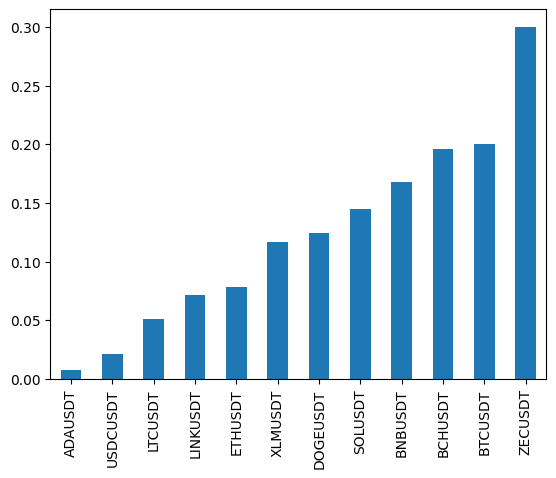

In [54]:
columns = ret.columns
def compute_stats(ret):
    mean = ret.mean()*365
    std = ret.std()*np.sqrt(365)  
    sharpe_ratio = mean / std
    hit_rate = (ret > 0).sum() / len(ret)
    df = pd.DataFrame(data=[mean, std, sharpe_ratio, hit_rate], 
                      index=['mean','std','sharpe_ratio','hit_rate'], 
                      columns=columns)
    return df

stats = compute_stats(ret)
print(stats)
# plot the sharpe_ratio row from the stats DataFrame (not from rets)
stats.loc['sharpe_ratio'].sort_values().plot(kind='bar')

In [55]:
mu = ret.mean()
sigma = ret.cov()

def optimal_weights(sigma,mu):
    wgt = np.linalg.inv(sigma) @ mu 
    wgt = wgt / np.abs(wgt).sum()
    return wgt

wgt = optimal_weights(sigma,mu)
combo = (ret*wgt).sum(1)
combo.mean()/combo.std()*np.sqrt(252)
wgt

array([ 0.2390643 , -0.15560459,  0.08434329,  0.02799107,  0.03725344,
       -0.07744872,  0.02764949, -0.1409063 ,  0.06823523, -0.0218247 ,
        0.07733181,  0.04234706])

In [56]:
price_2 = price_data.loc[:, pd.IndexSlice[:, ['open','high','low','close']]]

In [57]:
price_2 = price_2.rename(
    columns=lambda x: x.capitalize(),
    level=1
)

In [58]:
price_2

BTCUSDT                                ETHUSDT           \
                         Open      High       Low     Close     Open     High   
2022-01-14 00:00:00  42585.13  42780.42  42379.68  42659.64  3239.22  3274.41   
2022-01-14 04:00:00  42659.65  42965.43  42606.27  42608.43  3268.28  3312.00   
2022-01-14 08:00:00  42626.34  42684.34  41830.23  42017.84  3266.19  3274.29   
2022-01-14 12:00:00  41998.05  43342.01  41770.37  43107.95  3207.43  3298.50   
2022-01-14 16:00:00  43115.64  43411.31  42770.56  43091.54  3279.14  3326.69   
...                       ...       ...       ...       ...      ...      ...   
2026-03-19 04:00:00  71181.57  71199.40  69669.00  70194.36  2210.19  2211.79   
2026-03-19 08:00:00  70258.08  70518.64  69927.98  69927.98  2169.46  2190.92   
2026-03-19 12:00:00  69914.46  70223.01  68791.95  69524.70  2167.08  2167.40   
2026-03-19 16:00:00  69401.20  70583.87  69131.81  70239.67  2117.80  2154.00   
2026-03-19 20:00:00  70249.37  70655.06  70224.55  70464.65  2140.51  2152.61   

                                        BNBUSDT            ... LINKUSDT  \
                         Low    Close      Open      High  ...      Low   
2022-01-14 00:00:00  3223.64  3268.58  474.8511  481.8753  ...    25.10   
2022-01-14 04:00:00  3265.00  3265.00  480.2441  489.7394  ...    24.81   
2022-01-14 08:00:00  3196.21  3202.73  483.7786  483.7786  ...    23.97   
2022-01-14 12:00:00  3189.83  3275.66  472.1046  482.7921  ...    24.21   
2022-01-14 16:00:00  3258.88  3307.99  481.3555  486.6972  ...    24.60   
...                      ...      ...       ...       ...  ...      ...   
2026-03-19 04:00:00  2142.01  2166.91  652.3600  652.3600  ...     9.06   
2026-03-19 08:00:00  2158.64  2169.19  644.6400  648.6500  ...     9.11   
2026-03-19 12:00:00  2100.00  2119.00  643.9000  643.9000  ...     8.91   
2026-03-19 16:00:00  2105.41  2139.60  638.0200  641.3200  ...     8.92   
2026-03-19 20:00:00  2140.51  2145.59  640.3300  641.8800  ...     9.05   

                           ZECUSDT                          XLMUSDT           \
                     Close    Open    High     Low   Close     Open     High   
2022-01-14 00:00:00  25.20  142.10  145.30  141.60  141.60  0.26950  0.27111   
2022-01-14 04:00:00  24.94  141.50  142.20  140.30  142.20  0.26980  0.27860   
2022-01-14 08:00:00  24.07  142.10  142.10  137.40  138.00  0.27559  0.27575   
2022-01-14 12:00:00  24.72  138.50  142.40  138.10  142.40  0.26450  0.26988   
2022-01-14 16:00:00  24.93  140.80  143.80  140.80  143.60  0.26881  0.26967   
...                    ...     ...     ...     ...     ...      ...      ...   
2026-03-19 04:00:00   9.14  251.29  251.29  241.96  244.94  0.16980  0.16980   
2026-03-19 08:00:00   9.16  244.57  246.25  240.42  244.11  0.16750  0.16820   
2026-03-19 12:00:00   8.91  243.78  244.30  233.96  237.83  0.16540  0.16870   
2026-03-19 16:00:00   9.07  235.80  237.97  230.91  236.41  0.16420  0.16620   
2026-03-19 20:00:00   9.05  236.94  238.57  236.00  237.56  0.16560  0.16560   

                                       
                         Low    Close  
2022-01-14 00:00:00  0.26688  0.27017  
2022-01-14 04:00:00  0.26979  0.27549  
2022-01-14 08:00:00  0.26256  0.26490  
2022-01-14 12:00:00  0.26146  0.26803  
2022-01-14 16:00:00  0.26637  0.26843  
...                      ...      ...  
2026-03-19 04:00:00  0.16740  0.16740  
2026-03-19 08:00:00  0.16690  0.16810  
2026-03-19 12:00:00  0.16220  0.16420  
2026-03-19 16:00:00  0.16250  0.16620  
2026-03-19 20:00:00  0.16560  0.16560  

[9156 rows x 48 columns]

In [59]:
def breakout_long(price, X, Y):
    high = price['High']
    low = price['Low']

    # Rolling lookbacks (shifted 1 day to avoid look-ahead)
    Y_high = high.rolling(Y).max().shift(1)
    X_low = low.rolling(X).min().shift(1)

    # Signals
    long_entry = (high >= Y_high)
    long_exit  = (low <= X_low)

    # Position vector
    pos = np.zeros(len(price))
    for i in range(1, len(price)):
        pos[i] = pos[i-1]

        # Exit
        if pos[i] == 1 and long_exit.iloc[i]:
            pos[i] = 0

        # Entry
        if pos[i] == 0 and long_entry.iloc[i]:
            pos[i] = 1
    
    return pd.Series(pos, index=price.index)

In [60]:
def compute_heatmap(price_2, ret, max_Y=60, max_X=60):
    heatmap = np.full((max_X+1, max_Y+1), np.nan)

    for X in range(1, max_X+1):
        for Y in range(1, max_Y+1):

            # Only valid if X < Y (typical rule)
            if X >= Y:
                continue

            # Run strategy
            pos = breakout_long(price_2, X, Y)

            # Compute strategy returns
            strat_rets = pos * ret

            # Compute Sharpe
            sharpe = sharpe_ratio(strat_rets)

            heatmap[X, Y] = sharpe
    
    return heatmap

In [61]:
heat = compute_heatmap(price_2['BTCUSDT'], ret['BTCUSDT'], max_Y=60, max_X=60)

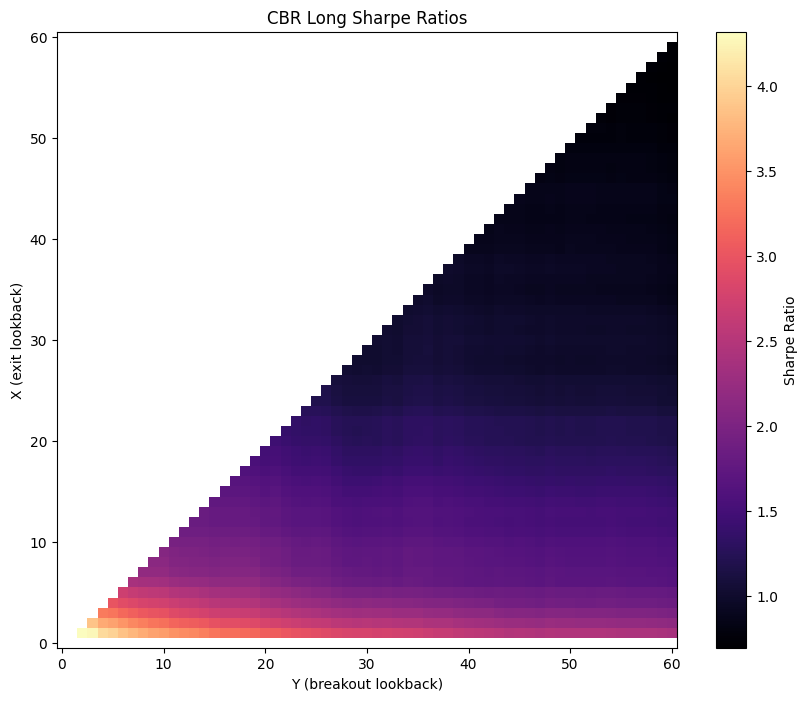

In [62]:
plt.figure(figsize=(10, 8))
plt.imshow(heat, 
           origin='lower', 
           aspect='auto', 
           cmap='magma')

plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Y (breakout lookback)")
plt.ylabel("X (exit lookback)")
plt.title("CBR Long Sharpe Ratios")

# Mask upper triangle (X ≥ Y)
for x in range(heat.shape[0]):
    for y in range(heat.shape[1]):
        if x >= y:
            heat[x, y] = np.nan

plt.imshow(heat, origin='lower', aspect='auto', cmap='magma')

plt.show()

In [63]:
def breakout_short(price, M, N):
    high = price['High']
    low = price['Low']

    # Rolling lookbacks (shifted 1 day to avoid look-ahead)
    # Use M for the high exit lookback and N for the low entry lookback
    M_high = high.rolling(M).max().shift(1)
    N_low  = low.rolling(N).min().shift(1)

    # Signals — keep them as boolean series and fill NaNs with False to avoid int-casting errors
    short_entry = (low <= N_low).fillna(False)
    short_exit  = (high >= M_high).fillna(False)

    # Position vector
    pos = np.zeros(len(price))
    for i in range(1, len(price)):
        pos[i] = pos[i-1]

        # Exit
        if pos[i] == -1 and short_exit.iloc[i]:
            pos[i] = 0

        # Entry
        if pos[i] == 0 and short_entry.iloc[i]:
            pos[i] = -1
    
    return pd.Series(pos, index=price.index)

In [64]:
def compute_heatmap_2(price_2, ret, max_M=60, max_N=60):
    heatmap_2 = np.full((max_M+1, max_N+1), np.nan)

    for M in range(1, max_M+1):
        for N in range(1, max_N+1):

            # Only valid if X < Y (typical rule)
            if M < N:
                continue

            # Run strategy
            pos = breakout_short(price_2, M, N)

            # Compute strategy returns
            strat_rets = pos * ret

            # Compute Sharpe
            sharpe = sharpe_ratio(strat_rets)

            heatmap_2[M, N] = sharpe
    
    return heatmap_2

In [65]:
heat = compute_heatmap_2(price_2['BTCUSDT'], ret['BTCUSDT'], max_M=60, max_N=60)

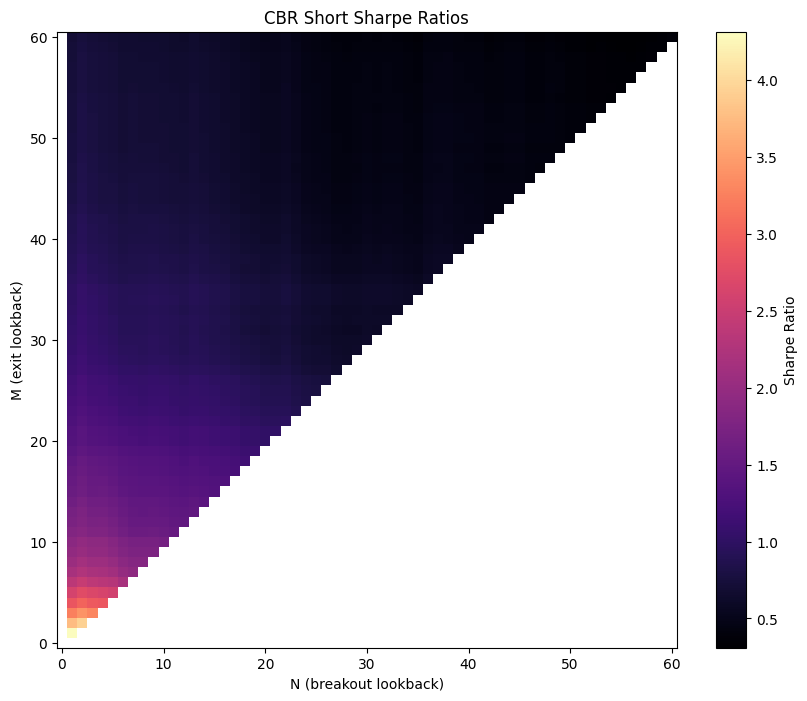

In [66]:
plt.figure(figsize=(10, 8))
plt.imshow(heat, 
           origin='lower', 
           aspect='auto', 
           cmap='magma')

plt.colorbar(label="Sharpe Ratio")
plt.xlabel("N (breakout lookback)")
plt.ylabel("M (exit lookback)")
plt.title("CBR Short Sharpe Ratios")

# Mask upper triangle (X ≥ Y)
for x in range(heat.shape[0]):
    for y in range(heat.shape[1]):
        if x >= y:
            heat[x, y] = np.nan

plt.imshow(heat, origin='lower', aspect='auto', cmap='magma')

plt.show()

In [67]:
positions = breakout_multi(price_2, X=2, Y=3, M=3, N=2)
positions

,BTCUSDT,ETHUSDT,BNBUSDT,USDCUSDT,SOLUSDT,LTCUSDT,DOGEUSDT,ADAUSDT,BCHUSDT,LINKUSDT,ZECUSDT,XLMUSDT
,position,position,position,position,position,position,position,position,position,position,position,position
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0
3,1.0,-1.0,-1.0,-1.0,-1.0,1.0,0.0,-1.0,1.0,-1.0,-1.0,-1.0
4,1.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9151,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
9152,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0
9153,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [68]:
positions = positions.copy()
positions.columns = positions.columns.get_level_values(0)
positions

,BTCUSDT,ETHUSDT,BNBUSDT,USDCUSDT,SOLUSDT,LTCUSDT,DOGEUSDT,ADAUSDT,BCHUSDT,LINKUSDT,ZECUSDT,XLMUSDT
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.0,-1.0,-1.0,0.0,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0
3,1.0,-1.0,-1.0,-1.0,-1.0,1.0,0.0,-1.0,1.0,-1.0,-1.0,-1.0
4,1.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9151,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
9152,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0
9153,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
9154,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [69]:
positions = positions.iloc[-len(ret):]
positions = pd.DataFrame(
    positions.values,
    index=ret.index[-len(positions):],
    columns=ret.columns
)

In [70]:
weights_history = []
portfolio_returns = []

quarter_ends = ret.resample('D').last().index

for i in range(4, len(quarter_ends)-1):

    train_end = quarter_ends[i]

    train_data = ret.loc[train_end - pd.DateOffset(years=2):train_end]

    mu = train_data.mean()
    sigma = train_data.cov()

    w = optimal_weights(sigma, mu)

    next_start = train_end
    next_end = quarter_ends[i+1]

    test_period = ret.loc[next_start:next_end]
    pos_test = positions.loc[next_start:next_end]

    # store portfolio returns
    port_ret = pos_test.shift(1) * test_period * w
    portfolio_returns.append(port_ret)

    # store weights for turnover calculation
    w_df = pd.DataFrame([w]*len(test_period), index=test_period.index, columns=ret.columns)
    weights_history.append(w_df)

portfolio = pd.concat(portfolio_returns)
weights = pd.concat(weights_history)

<Axes: >

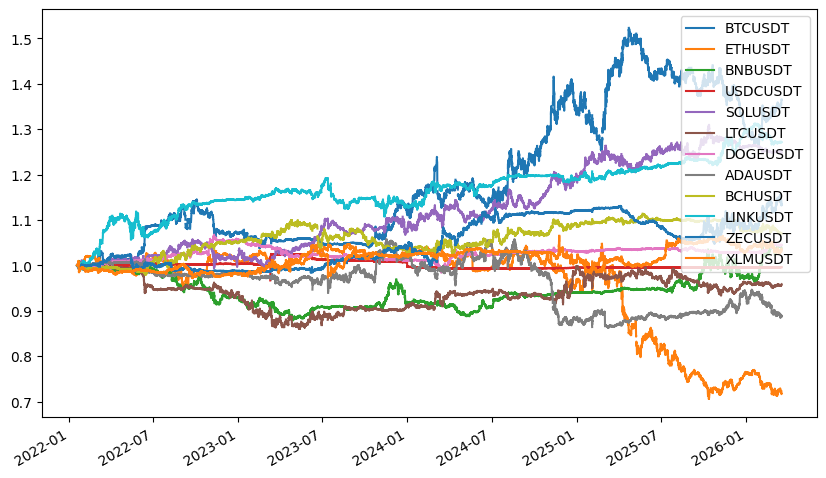

In [71]:
strategy_returns = portfolio
(strategy_returns + 1).cumprod().plot(figsize=(10,6))

In [72]:
print((positions.diff().abs().sum(1) > 0).mean())

0.809393773894047


In [73]:
sharpe_ratio(strategy_returns)

BTCUSDT     0.296130
ETHUSDT    -0.284637
BNBUSDT     0.067147
USDCUSDT   -0.008343
SOLUSDT     0.320808
LTCUSDT    -0.046023
DOGEUSDT    0.153968
ADAUSDT    -0.122820
BCHUSDT     0.138075
LINKUSDT    0.417464
ZECUSDT     0.212647
XLMUSDT     0.074655
dtype: float64

In [74]:
portfolio_daily_return = strategy_returns.sum(axis=1)
portfolio_daily_return

2022-01-18 00:00:00    0.000000
2022-01-18 04:00:00   -0.000630
2022-01-18 08:00:00    0.000406
2022-01-18 12:00:00    0.000021
2022-01-18 16:00:00    0.000147
                         ...   
2026-03-18 08:00:00   -0.000658
2026-03-18 12:00:00   -0.008312
2026-03-18 16:00:00    0.004132
2026-03-18 20:00:00    0.000849
2026-03-19 00:00:00   -0.002907
Length: 10647, dtype: float64

<Axes: >

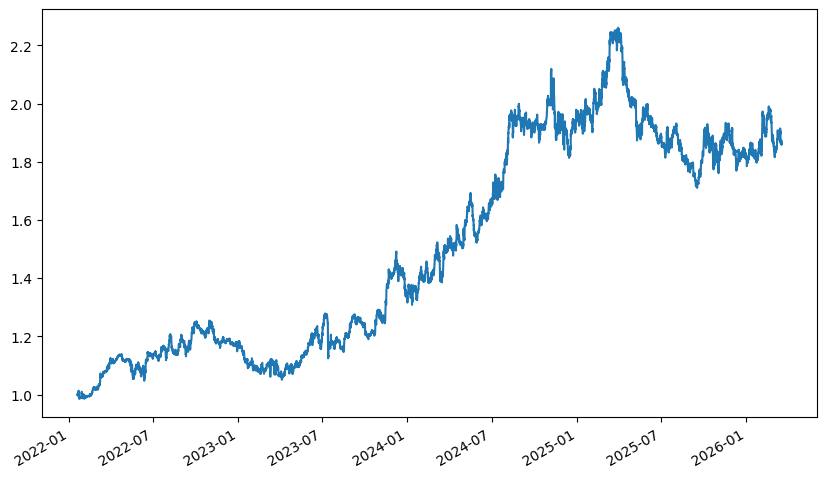

In [75]:
(portfolio_daily_return+1).cumprod().plot(figsize=(10,6))

In [76]:
sharpe_ratio(portfolio_daily_return)

np.float64(0.3233700338590881)

<Axes: >

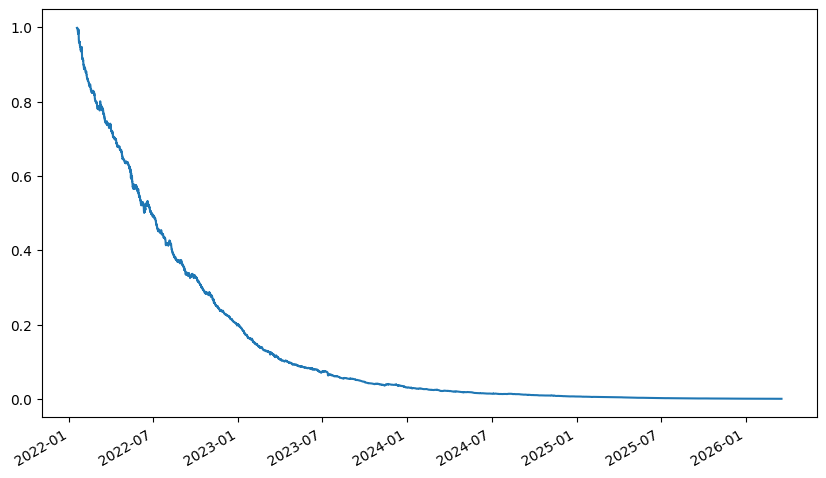

In [77]:
strategy_returns = portfolio.sum(axis=1)

exposure = positions.loc[weights.index] * weights

to = (exposure.fillna(0) - exposure.shift().fillna(0)).abs().sum(axis=1)

net_ret = strategy_returns - to * 20 * 1e-4

(net_ret + 1).cumprod().plot(figsize=(10,6))

In [78]:
sharpe_ratio(net_ret)

np.float64(-3.2309179215665593)

In [79]:
print("Average turnover:", to.mean())
print("Average cost:", (to * 20 * 1e-4).mean())
print("Average return:", strategy_returns.mean())

Average turnover: 0.37204396996007383
Average cost: 0.0007440879399201476
Average return: 6.601295849631142e-05


In [80]:
benchmark = ret.mean(axis=1)

In [81]:
weights_history = []
portfolio_returns = []

dates = ret.index

for i in range(4, len(dates)-1):

    train_end = dates[i]

    train_data = ret.loc[train_end - pd.DateOffset(years=2):train_end]

    mu = train_data.mean()
    sigma = train_data.cov()

    w = optimal_weights(sigma, mu)

    next_start = train_end
    next_end = dates[i+1]

    test_period = ret.loc[next_start:next_end]
    pos_test = positions.loc[next_start:next_end]

    port_ret = pos_test.shift(1) * test_period * w
    portfolio_returns.append(port_ret)

    w_df = pd.DataFrame([w]*len(test_period),
                        index=test_period.index,
                        columns=ret.columns)
    weights_history.append(w_df)

portfolio = pd.concat(portfolio_returns).sum(axis=1)
weights = pd.concat(weights_history)

benchmark = benchmark.loc[portfolio.index]

split = int(len(portfolio)*0.8)

train_strategy = portfolio.iloc[:split]
test_strategy  = portfolio.iloc[split:]

benchmark_train = benchmark.iloc[:split]
benchmark_test  = benchmark.iloc[split:]

import statsmodels.api as sm

X_train = sm.add_constant(benchmark_train)
model_train = sm.OLS(train_strategy, X_train).fit()

X_test = sm.add_constant(benchmark_test)
model_test = sm.OLS(test_strategy, X_test).fit()

print("Train alpha t-stat:", model_train.tvalues['const'])
print("Test alpha t-stat:", model_test.tvalues['const'])

Train alpha t-stat: 1.996035090422987
Test alpha t-stat: -0.06009221389661895


In [82]:
print(model_train.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     4.536
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0332
Time:                        14:54:44   Log-Likelihood:                 64286.
No. Observations:               14640   AIC:                        -1.286e+05
Df Residuals:                   14638   BIC:                        -1.286e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.945e-05   2.48e-05      1.996      0.0

In [83]:
print(model_test.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     22.46
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           2.23e-06
Time:                        14:54:44   Log-Likelihood:                 16154.
No. Observations:                3660   AIC:                        -3.230e+04
Df Residuals:                    3658   BIC:                        -3.229e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.911e-06   4.84e-05     -0.060      0.9

In [84]:
net_ret = net_ret.groupby(net_ret.index).sum()
benchmark = benchmark.groupby(benchmark.index).mean()

In [85]:
data = pd.concat([net_ret, benchmark], axis=1)
data.columns = ['strategy', 'benchmark']

# remove NaN / inf
data = data.replace([np.inf, -np.inf], np.nan).dropna()

split = int(len(data)*0.8)

train = data.iloc[:split]
test  = data.iloc[split:]
train_strategy = train['strategy']
benchmark_train = train['benchmark']

test_strategy = test['strategy']
benchmark_test = test['benchmark']

import statsmodels.api as sm

X_train = sm.add_constant(benchmark_train)
model_train = sm.OLS(train_strategy, X_train).fit()

X_test = sm.add_constant(benchmark_test)
model_test = sm.OLS(test_strategy, X_test).fit()

print("Train alpha t-stat:", model_train.tvalues['const'])
print("Test alpha t-stat:", model_test.tvalues['const'])

Train alpha t-stat: -15.304409599412754
Test alpha t-stat: -8.48041771385404


In [86]:
print(model_train.summary())

                            OLS Regression Results                            
Dep. Variable:               strategy   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7487
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.387
Time:                        14:54:44   Log-Likelihood:                 29400.
No. Observations:                7301   AIC:                        -5.880e+04
Df Residuals:                    7299   BIC:                        -5.878e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008   5.05e-05    -15.304      0.0

In [87]:
print(model_test.summary())

                            OLS Regression Results                            
Dep. Variable:               strategy   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     23.54
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.33e-06
Time:                        14:54:44   Log-Likelihood:                 7345.8
No. Observations:                1826   AIC:                        -1.469e+04
Df Residuals:                    1824   BIC:                        -1.468e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0009      0.000     -8.480      0.0

In [88]:
closing_data = price_data[[('BTCUSDT', 'close'), ('ETHUSDT', 'close'), ('BNBUSDT', 'close'), ('USDCUSDT', 'close'),
                            ('SOLUSDT', 'close'), ('LTCUSDT', 'close'), ('DOGEUSDT', 'close'), ('ADAUSDT', 'close'),
                            ('BCHUSDT', 'close'), ('LINKUSDT', 'close'), ('ZECUSDT', 'close'), ('XLMUSDT', 'close')]]
closing_data = closing_data.droplevel(1, axis=1)

In [89]:
closing_data = pd.DataFrame(closing_data)
closing_data

,BTCUSDT,ETHUSDT,BNBUSDT,USDCUSDT,SOLUSDT,LTCUSDT,DOGEUSDT,ADAUSDT,BCHUSDT,LINKUSDT,ZECUSDT,XLMUSDT
2022-01-14 00:00:00,42659.64,3268.58,480.8159,0.9998,147.7462,138.27,0.175999,1.24693,383.41,25.20,141.60,0.27017
2022-01-14 04:00:00,42608.43,3265.00,484.2211,0.9995,147.5973,138.72,0.196018,1.28331,387.98,24.94,142.20,0.27549
2022-01-14 08:00:00,42017.84,3202.73,472.1416,0.9994,143.3609,138.51,0.188406,1.23350,380.61,24.07,138.00,0.26490
2022-01-14 12:00:00,43107.95,3275.66,481.4952,0.9998,147.0490,144.74,0.194120,1.26562,389.78,24.72,142.40,0.26803
2022-01-14 16:00:00,43091.54,3307.99,486.1436,0.9998,148.3940,144.64,0.187657,1.26316,388.18,24.93,143.60,0.26843
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-19 04:00:00,70194.36,2166.91,646.3800,1.0003,89.5900,55.48,0.094470,0.26970,453.90,9.14,244.94,0.16740
2026-03-19 08:00:00,69927.98,2169.19,645.1200,0.9998,89.5600,55.56,0.093860,0.26910,456.00,9.16,244.11,0.16810
2026-03-19 12:00:00,69524.70,2119.00,638.1100,1.0000,87.7300,54.78,0.093020,0.26530,454.60,8.91,237.83,0.16420
2026-03-19 16:00:00,70239.67,2139.60,641.3000,0.9998,88.8400,55.63,0.094010,0.26760,455.90,9.07,236.41,0.16620


In [90]:
def EMA(rets, window = 34):
    ema = rets.ewm(span=window, adjust=False).mean()
    return ema

def EMA_2(rets, window = 18):
    ema_2 = rets.ewm(span=window, adjust=False).mean()
    return ema_2


In [91]:
ema = EMA(closing_data, window=90)
ema_2 = EMA(closing_data, window=180)

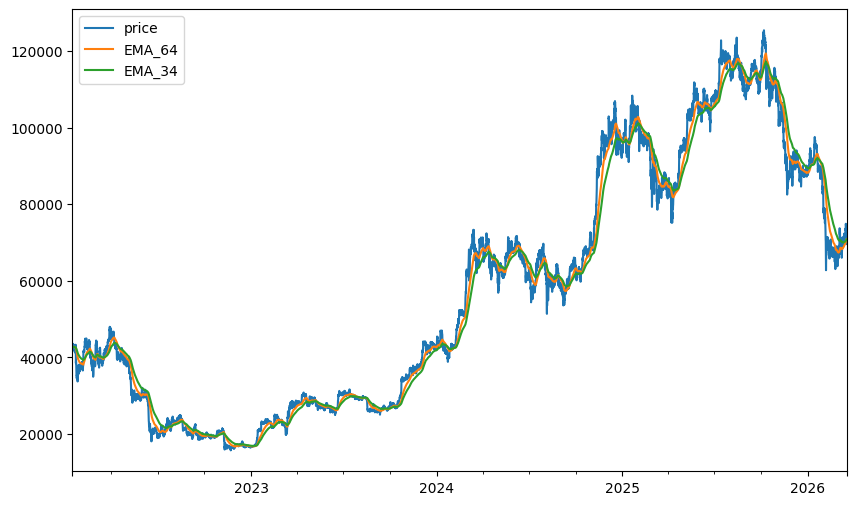

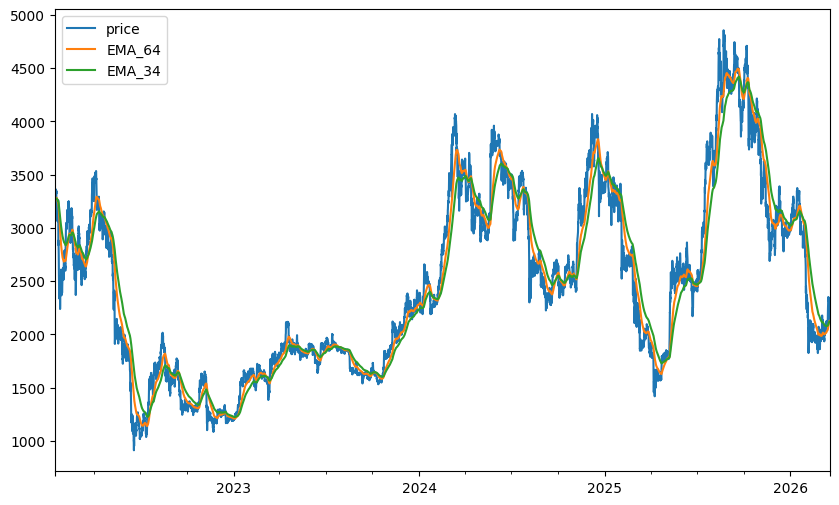

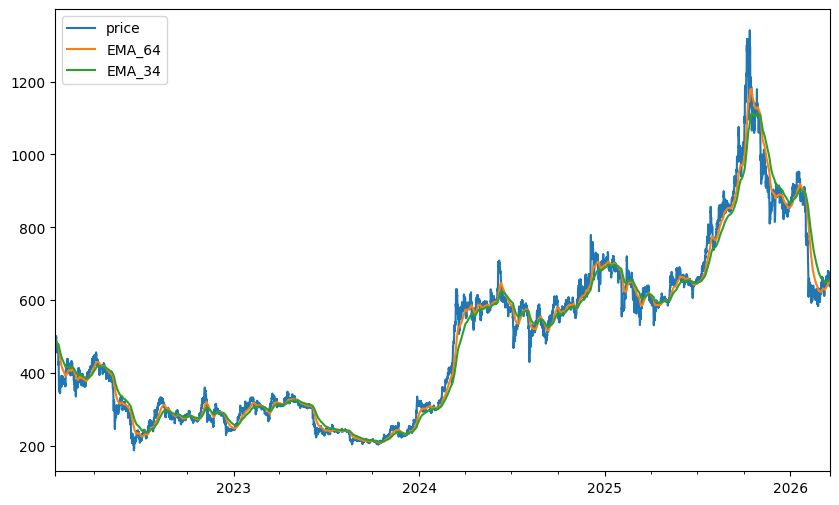

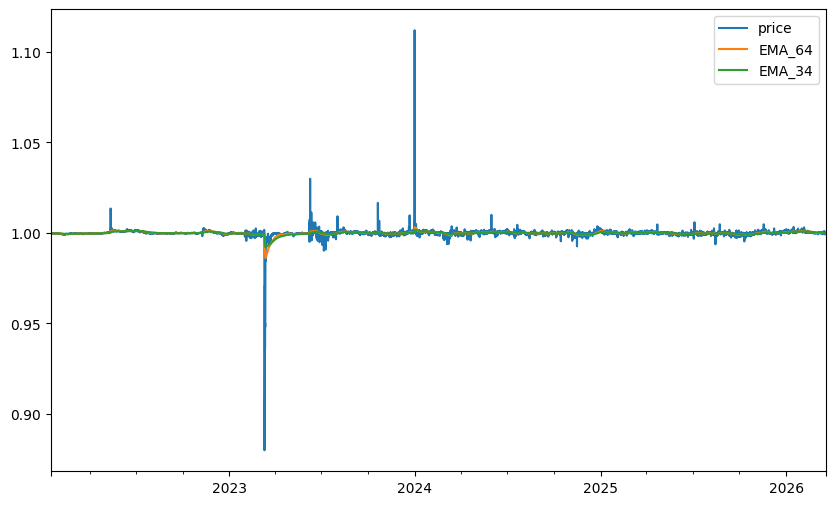

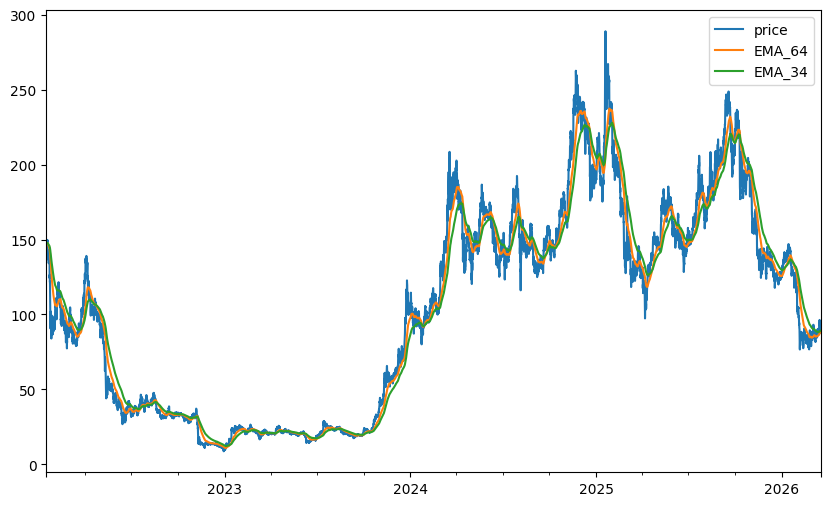

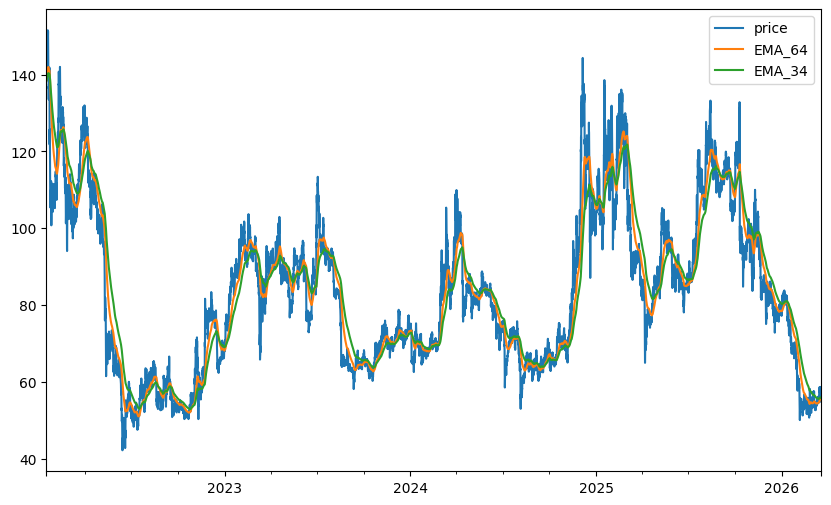

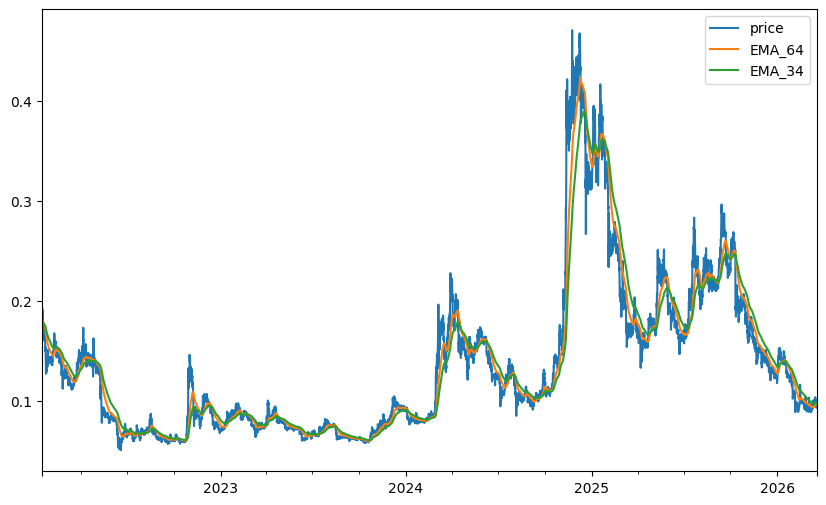

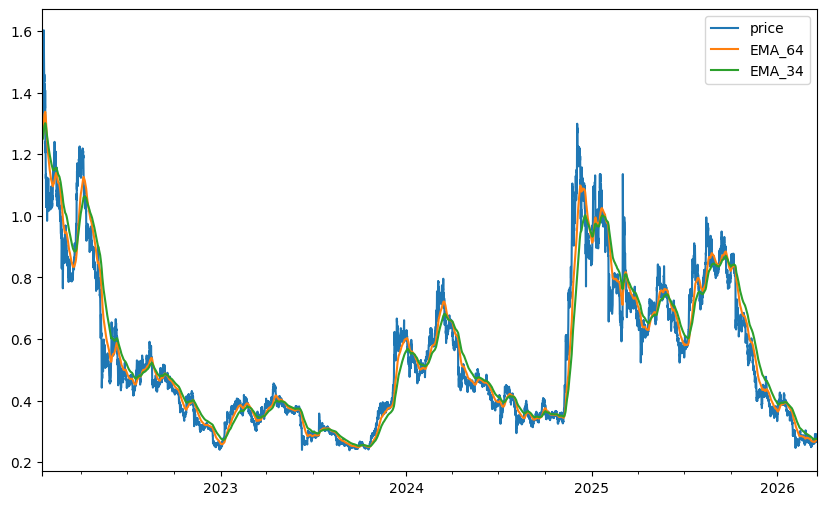

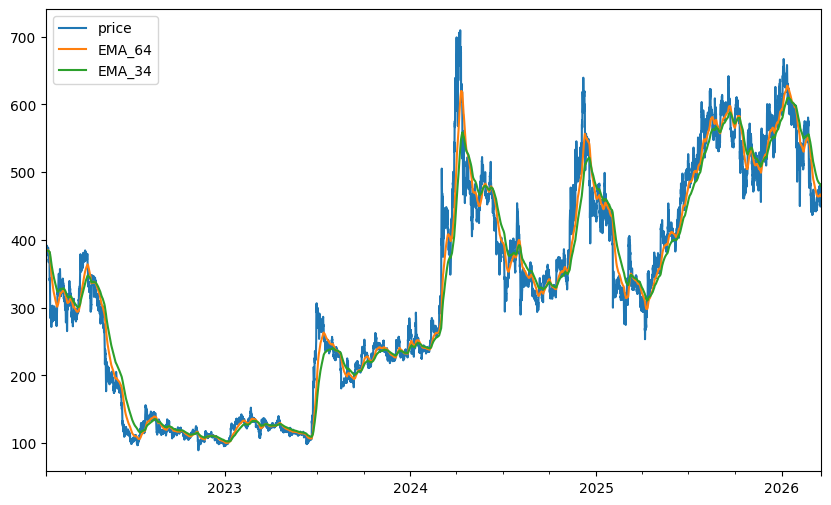

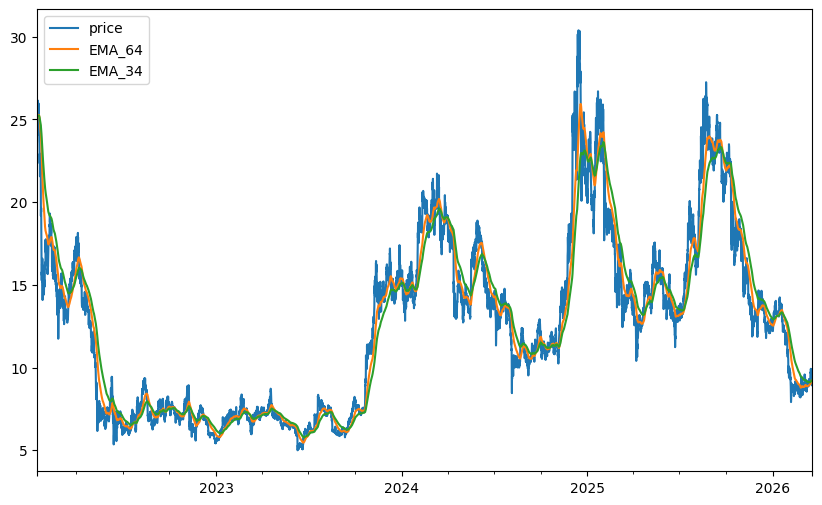

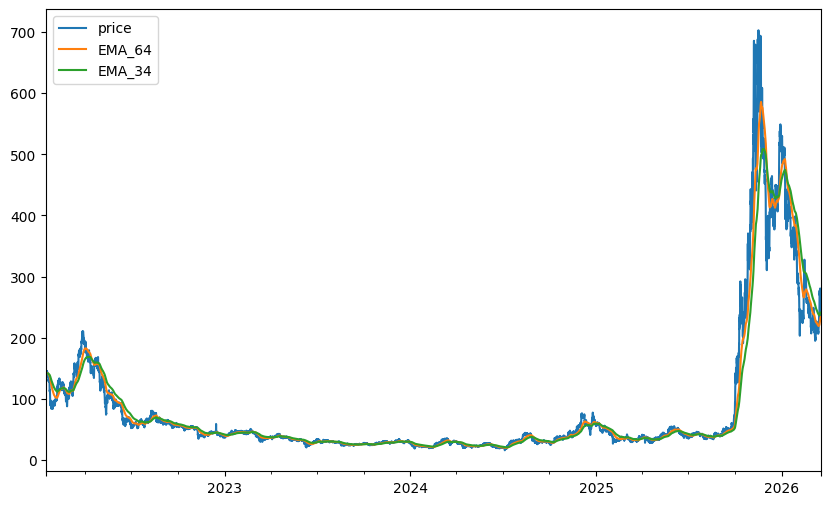

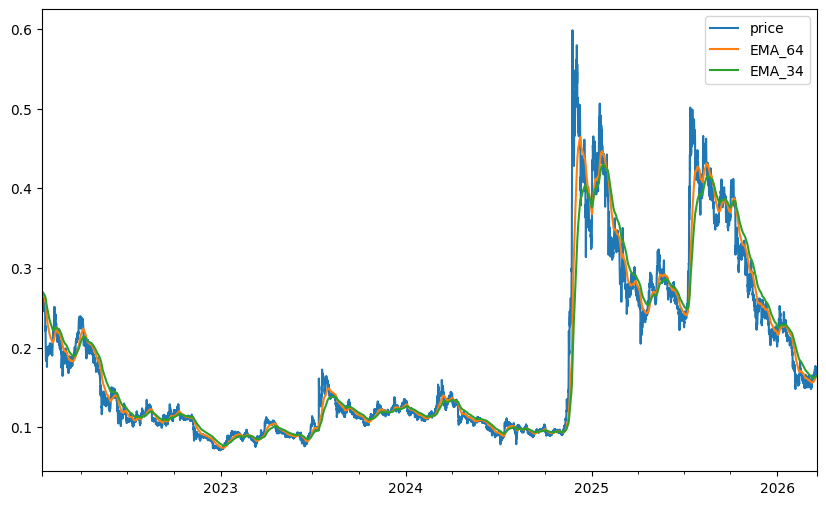

In [92]:
data = []

for i in closing_data.columns:
    stock = pd.DataFrame({
        'price'  : closing_data[i],
        'EMA_64' : ema[i],
        'EMA_34' : ema_2[i],
        'ticker' : i
    })

    stock[['price', 'EMA_64', 'EMA_34']].plot(figsize=(10,6))

    data.append(stock)


In [93]:
combined_df = pd.concat(data, axis=0)
combined_df

,price,EMA_64,EMA_34,ticker
2022-01-14 00:00:00,42659.6400,42659.640000,42659.640000,BTCUSDT
2022-01-14 04:00:00,42608.4300,42658.514505,42659.074144,BTCUSDT
2022-01-14 08:00:00,42017.8400,42644.433747,42651.988683,BTCUSDT
2022-01-14 12:00:00,43107.9500,42654.620918,42657.026930,BTCUSDT
2022-01-14 16:00:00,43091.5400,42664.223535,42661.828179,BTCUSDT
...,...,...,...,...
2026-03-19 04:00:00,0.1674,0.164025,0.164286,XLMUSDT
2026-03-19 08:00:00,0.1681,0.164115,0.164328,XLMUSDT
2026-03-19 12:00:00,0.1642,0.164117,0.164327,XLMUSDT
2026-03-19 16:00:00,0.1662,0.164163,0.164347,XLMUSDT


In [94]:
def ema_signal(df):
    diff = df['EMA_34'] - df['EMA_64']
    signal = np.sign(diff).fillna(0).astype(int)
    return pd.Series(signal, index=df.index)

signals = (
    combined_df
    .groupby('ticker', group_keys=False)
    .apply(ema_signal)
    .T
    .reindex(columns=ret.columns)
)

C:\Users\david\AppData\Local\Temp\ipykernel_27360\430733667.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(ema_signal)


In [95]:
signals

,BTCUSDT,ETHUSDT,BNBUSDT,USDCUSDT,SOLUSDT,LTCUSDT,DOGEUSDT,ADAUSDT,BCHUSDT,LINKUSDT,ZECUSDT,XLMUSDT
2022-01-14 00:00:00,0,0,0,0,0,0,0,0,0,0,0,0
2022-01-14 04:00:00,1,1,-1,1,1,-1,-1,-1,-1,1,-1,-1
2022-01-14 08:00:00,1,1,1,1,1,-1,-1,-1,-1,1,1,1
2022-01-14 12:00:00,1,1,1,1,1,-1,-1,-1,-1,1,1,1
2022-01-14 16:00:00,-1,1,-1,1,1,-1,-1,-1,-1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-19 04:00:00,-1,-1,1,1,1,1,1,1,1,1,1,1
2026-03-19 08:00:00,-1,-1,1,1,1,1,1,1,1,1,1,1
2026-03-19 12:00:00,-1,-1,1,1,1,1,1,1,1,1,1,1
2026-03-19 16:00:00,-1,-1,1,1,1,1,1,1,1,1,1,1


In [96]:
weights_history = []
portfolio_returns = []

quarter_ends = ret.resample('100D').last().index

for i in range(4, len(quarter_ends)-1):

    train_end = quarter_ends[i]

    train_data = ret.loc[train_end - pd.DateOffset(years=2):train_end]

    mu = train_data.mean()
    sigma = train_data.cov()

    w = optimal_weights(sigma, mu)

    next_start = train_end
    next_end = quarter_ends[i+1]

    test_period = ret.loc[next_start:next_end]
    pos_test = signals.loc[next_start:next_end]

    # store portfolio returns
    port_ret = pos_test.shift(1) * test_period * w
    portfolio_returns.append(port_ret)

    # store weights for turnover calculation
    w_df = pd.DataFrame([w]*len(test_period), index=test_period.index, columns=ret.columns)
    weights_history.append(w_df)

portfolio = pd.concat(portfolio_returns)
weights = pd.concat(weights_history)

<Axes: >

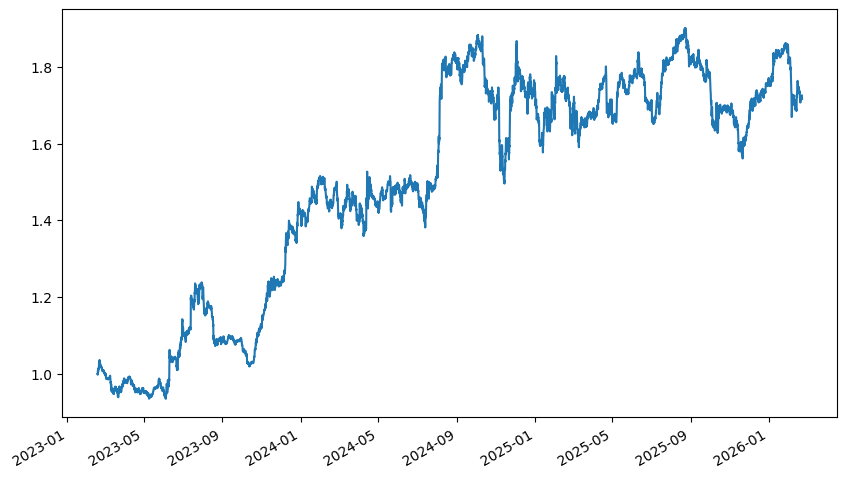

In [97]:
stocks_rets = portfolio.sum(axis=1)
(1+stocks_rets).cumprod().plot(figsize=(10,6))

<Axes: >

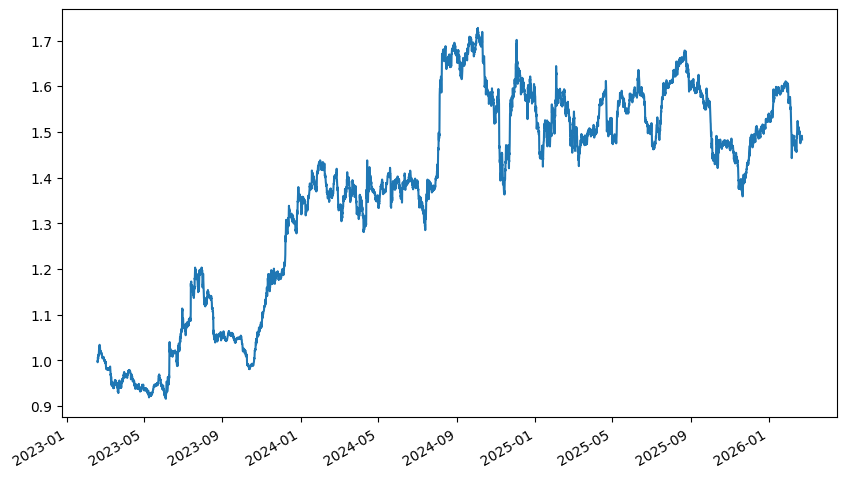

In [98]:
strategy_returns = portfolio.sum(axis=1)

exposure = signals.loc[weights.index] * weights

to = (exposure.fillna(0) - exposure.shift().fillna(0)).abs().sum(axis=1)

net_ret = strategy_returns - to * 20 * 1e-4

(net_ret + 1).cumprod().plot(figsize=(10,6))

In [99]:
sharpe_ratio(net_ret)

np.float64(0.2892695359102419)

In [100]:
weights_history = []
portfolio_returns = []

quarter_ends = ret.resample('100D').last().index

for i in range(4, len(quarter_ends)-1):

    train_end = quarter_ends[i]

    train_data = ret.loc[train_end - pd.DateOffset(years=2):train_end]

    mu = train_data.mean()
    sigma = train_data.cov()

    w = optimal_weights(sigma, mu)

    next_start = train_end + pd.Timedelta(days=1)
    next_end = quarter_ends[i+1]

    test_period = ret.loc[next_start:next_end]
    pos_test = signals.loc[next_start:next_end]

    port_ret = pos_test.shift(1) * test_period * w
    portfolio_returns.append(port_ret)

portfolio = pd.concat(portfolio_returns).sum(axis=1)

data = pd.concat([portfolio, benchmark], axis=1)
data.columns = ['strategy','benchmark']
data = data.replace([np.inf, -np.inf], np.nan).dropna()

split = int(len(data)*0.8)

train = data.iloc[:split]
test  = data.iloc[split:]

train_strategy = train['strategy']
benchmark_train = train['benchmark']

test_strategy = test['strategy']
benchmark_test = test['benchmark']

import statsmodels.api as sm

X_train = sm.add_constant(benchmark_train)
model_train = sm.OLS(train_strategy, X_train).fit()

X_test = sm.add_constant(benchmark_test)
model_test = sm.OLS(test_strategy, X_test).fit()

print("Train alpha t-stat:", model_train.tvalues['const'])
print("Test alpha t-stat:", model_test.tvalues['const'])

Train alpha t-stat: 1.8671297016217152
Test alpha t-stat: 0.16807470933646984


In [101]:
print(model_train.summary())

                            OLS Regression Results                            
Dep. Variable:               strategy   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2943
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.588
Time:                        14:54:46   Log-Likelihood:                 20428.
No. Observations:                5236   AIC:                        -4.085e+04
Df Residuals:                    5234   BIC:                        -4.084e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001   6.76e-05      1.867      0.0

In [102]:
print(model_test.summary())

                            OLS Regression Results                            
Dep. Variable:               strategy   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.03175
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.859
Time:                        14:54:46   Log-Likelihood:                 5538.9
No. Observations:                1309   AIC:                        -1.107e+04
Df Residuals:                    1307   BIC:                        -1.106e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.635e-05   9.73e-05      0.168      0.8

<Axes: >

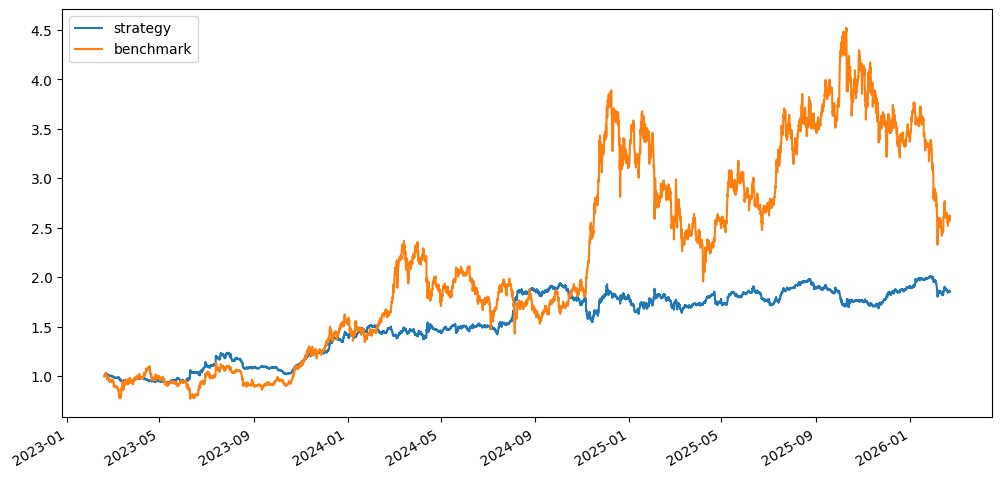

In [103]:
(data + 1).cumprod().plot(figsize=(12,6))

In [104]:
sharpe_ratio(data['strategy'])

np.float64(0.4316467218631198)

In [105]:
net_ret = net_ret.groupby(net_ret.index).sum()
benchmark = benchmark.groupby(benchmark.index).mean()

In [106]:
data = pd.concat([net_ret, benchmark], axis=1)
data.columns = ['strategy', 'benchmark']

# remove NaN / inf
data = data.replace([np.inf, -np.inf], np.nan).dropna()

split = int(len(data)*0.8)

train = data.iloc[:split]
test  = data.iloc[split:]
train_strategy = train['strategy']
benchmark_train = train['benchmark']

test_strategy = test['strategy']
benchmark_test = test['benchmark']

import statsmodels.api as sm

X_train = sm.add_constant(benchmark_train)
model_train = sm.OLS(train_strategy, X_train).fit()

X_test = sm.add_constant(benchmark_test)
model_test = sm.OLS(test_strategy, X_test).fit()

print("Train alpha t-stat:", model_train.tvalues['const'])
print("Test alpha t-stat:", model_test.tvalues['const'])

Train alpha t-stat: 1.3972253744858272
Test alpha t-stat: -0.2601672761586723


In [107]:
print(model_train.summary())

                            OLS Regression Results                            
Dep. Variable:               strategy   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.02858
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.866
Time:                        14:54:46   Log-Likelihood:                 20592.
No. Observations:                5280   AIC:                        -4.118e+04
Df Residuals:                    5278   BIC:                        -4.117e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.422e-05   6.74e-05      1.397      0.1

In [108]:
print(model_test.summary())

                            OLS Regression Results                            
Dep. Variable:               strategy   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1902
Date:                Thu, 19 Mar 2026   Prob (F-statistic):              0.663
Time:                        14:54:46   Log-Likelihood:                 5579.5
No. Observations:                1321   AIC:                        -1.115e+04
Df Residuals:                    1319   BIC:                        -1.114e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.539e-05   9.76e-05     -0.260      0.7